# ARGUS-FEDER — How does helium affect deuterium retention in tungsten?

This notebook shows **ARGUS**, a notebook-native AI agent, working on one
question and three follow-ups. The questions are typed in plain English into an
`%%ask` cell. The agent decides what to look up, writes and runs its own code,
and reports back.

**Who wrote what.** This introduction and the short note above each question are
written by us, at SDSC. Everything inside and below an `%%ask` cell is the
agent's own: the steps it took, the code it wrote, the figures and the answer.
The questions themselves were written with Greg Sinclair and Yiming Chen, whose
group produced the data.

## The question

A burning plasma produces helium and neutrons due to the fusion of hydrogen
isotopes. The first wall surfaces in a fusion device are bombarded by these
species with varying intensities. The degree to which implanted helium affects
the accumulation of implanted hydrogenic particles (deuterium and tritium) in
the plasma-facing walls is a first-order question for a reactor, as it impacts
the safety and fuel economy of the overall plant.

The delivery this notebook works from was built to ask exactly that. Tungsten
coupons were pre-exposed to helium plasma in the PISCES-A linear device at two
temperatures. Then, both these exposed samples and pristine samples were
subsequently exposed to deuterium plasma in the DIII-D tokamak via the DiMES
sample exposure probe. The retention of hydrogenic and helium species was
measured afterwards by three laboratory techniques.

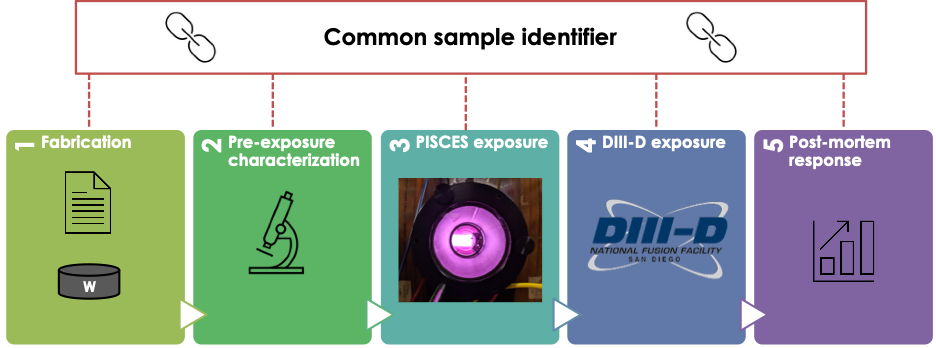

*Each coupon carries one identifier through every stage, which is what makes a
question about the end of its life answerable from the beginning of it.*

The question is asked plainly first. The follow-ups then press on the two places
where a single number could mislead: which technique produced it, and which
plasma the coupon saw. The last question asks what the data cannot support.


In [ ]:
%reset

## 1 — The question, as asked

Put plainly, the way it would be asked in a meeting, with no constraint on how
it should be answered.


I’ll identify comparable tungsten samples with and without helium exposure, quantify deuterium retention, and interpret the measured difference with supporting metadata.

I’m reading the materials data workflow to locate retention, composition, and exposure fields needed for a controlled comparison.

I’m checking prior query lessons so the lakehouse calls preserve sample identity, measurement method, and uncertainty correctly.

The retention question also asks for mechanism, so I’m reading the attached-literature search workflow before querying the experiment’s papers.

The workflow is defined; I’m advancing to a batched query of all coupons, exposure cells, retention methods, delivery notes, and attached papers.

...

I’m checking the saved exposure table to report how the 600 K and 800 K helium treatments differed beyond temperature.

The calculated effects are complete; I’m marking the quantitative comparison and figures finished, then auditing output files and methodological caveats.

I’m listing the working folder to confirm every CSV, figure, script, and cached SEM source remained available for verification.

The audit confirms all analyses succeeded on their first execution, no script was edited and retried, and all reported numbers are saved in CSV/JSON files.

**Bottom line** : Helium did **not** have one uniform effect on deuterium retention in these tungsten coupons. A 600 K helium pre-exposure generally increased measured retention, whereas an 800 K pre-exposure strongly reduced retention after H-mode exposure; after L-mode exposure, helium increased near-surface deuterium while reducing the deeper inventory, indicating redistribution toward the surface rather than a simple increase or decrease everywhere.

## Measured effect

Each percentage below compares a helium-pre-exposed coupon with the no-helium coupon from the **same DIII-D plasma regime** . The techniques are kept separate because they probe different depths and the provider explicitly advises against averaging or ranking them.

| DIII-D regime | Helium pre-exposure | ERDA total | NRA surface, 0–0.5 µm | NRA sub-surface, 0.5–3 µm | LAMS integral, 0.024–2.155 µm |
|---|---:|---:|---:|---:|---:|
| H-mode | 600 K | +27% | +14% | +33% | +68% |
| H-mode | 800 K | −42% | −68% | −77% | −50% |
| L-mode | 600 K | +63% | +121% | −24% | −4% |
| L-mode | 800 K | +36% | +35% | −59% | −33% |

The ERDA absolute totals were:

- **H-mode control** : $1.16\times10^{15}$ D atoms cm$^{-2}$.
  - After 600 K He: $1.47\times10^{15}$ atoms cm$^{-2}$, a ratio of $1.27\pm0.09$ to the control.
  - After 800 K He: $6.68\times10^{14}$ atoms cm$^{-2}$, a ratio of $0.576\pm0.052$.
- **L-mode control** : $1.47\times10^{15}$ D atoms cm$^{-2}$.
  - After 600 K He: $2.40\times10^{15}$ atoms cm$^{-2}$, a ratio of $1.63\pm0.10$.
  - After 800 K He: $2.00\times10^{15}$ atoms cm$^{-2}$, a ratio of $1.36\pm0.09$.

Those propagated uncertainties use the ERDA-reported standard deviations. NRA supplied no uncertainty column, while the LAMS integral is a derived trapezoidal integration of the measured profile and was not assigned an integrated uncertainty.


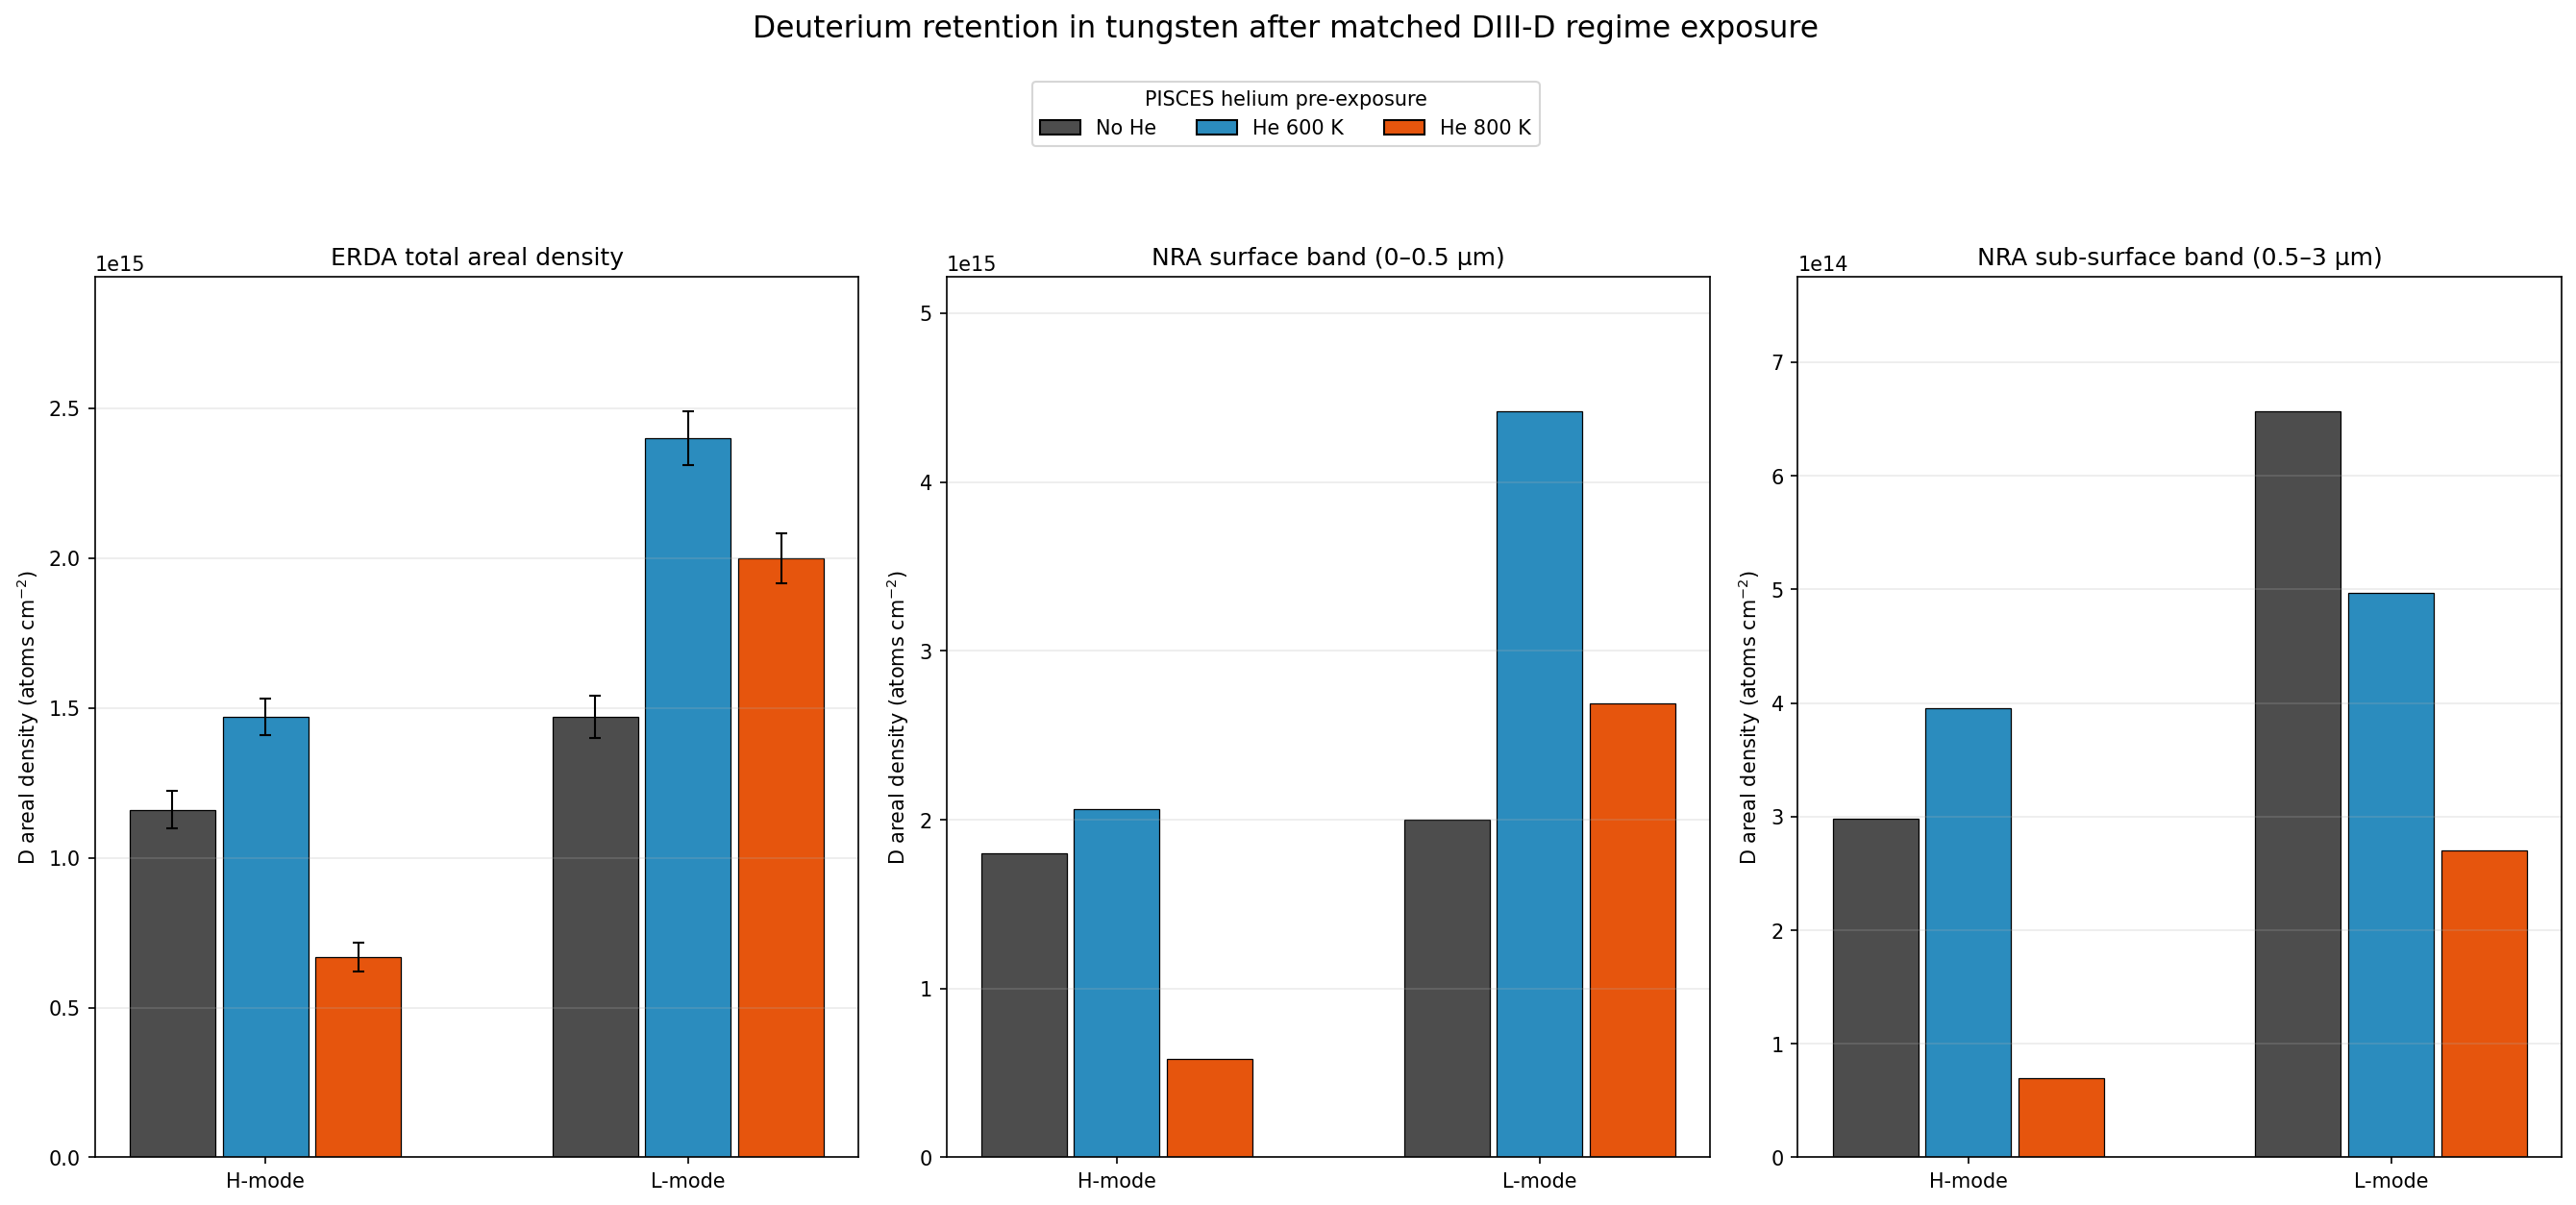

## What the depth measurements imply

The L-mode results are especially informative. ERDA and surface NRA recorded more deuterium after helium exposure, but NRA below 0.5 µm and the integrated LAMS profiles recorded less—particularly for the 800 K treatment. Thus, in that regime helium appears to have produced a **shallower D distribution** , with enrichment close to the surface but reduced penetration or retention at depth.

The LAMS profiles also show local reversals with depth: every treatment has some sampled depths above and others below its no-He control. Consequently, even the integrated LAMS percentages should be understood as summaries of a nonuniform profile, not as evidence that helium changed retention by the same factor throughout the tungsten.


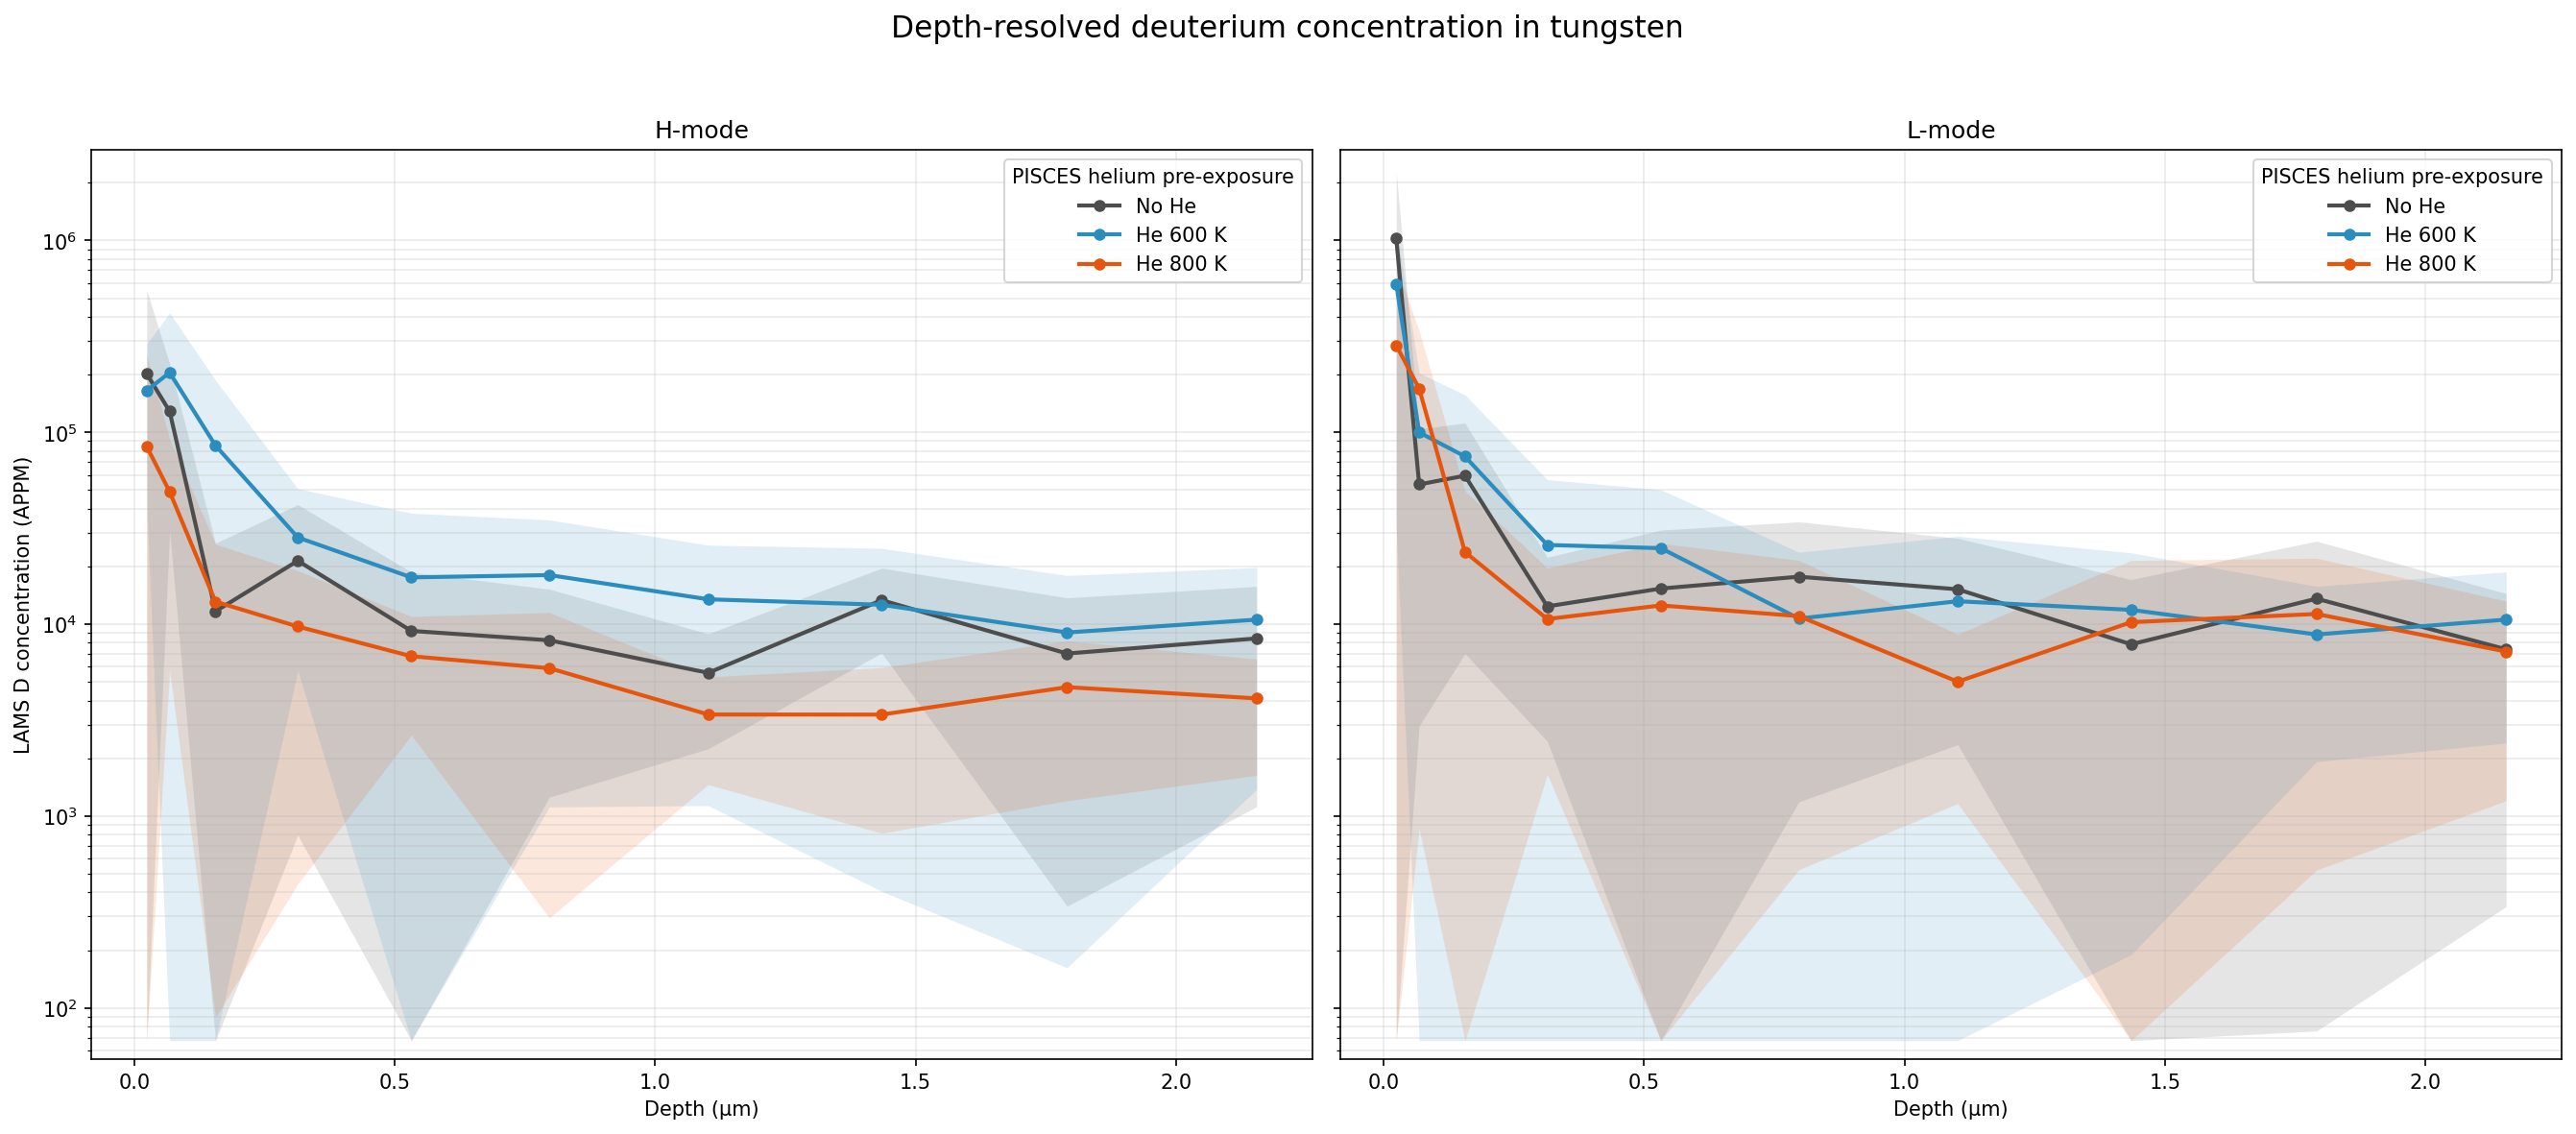

## Likely physical explanation

The attached Baldwin and Doerner study provides relevant physical context, although it concerns its own PISCES experiments rather than these particular coupons. It reports that a helium-affected, nanobubble-rich near-surface layer can modify deuterium transport in two related ways:

1. It can act as a **near-surface permeation barrier** , changing the effective migration of D through tungsten.
2. It can alter **recycling at the exposed surface** , reducing the fraction of incoming D that penetrates deeply and allowing more rapid return to the plasma.

Their modeling concluded that bubble porosity alone was insufficient; changes in migration energy and altered recycling were both needed to reproduce the reduced hydrogen-isotope inventory and shallow profiles. That framework is consistent with the strong H-mode reductions after the 800 K treatment and with the L-mode combination of surface enhancement and deeper depletion.

The delivered SEM record also shows that helium treatment altered the pre-DIII-D surface state. At matched settings—JSM-7000F, 10 kV, 50,000×—the mean grayscale-gradient statistic was:

- **Pristine W** : $0.00874\pm0.00063$ per pixel across 4 images.
- **He at 600 K** : $0.01263\pm0.00331$ across 6 images, approximately 44% above pristine.
- **He at 800 K** : $0.01433\pm0.00390$ across 8 images, approximately 64% above pristine.

This is descriptive evidence of increased visible surface texture after helium treatment, not a direct measurement of nanobubble density or proof of the transport mechanism. These images were recorded after the PISCES treatment but before DIII-D exposure; the delivery contains no later SEM stage showing what the subsequent deuterium exposure did.


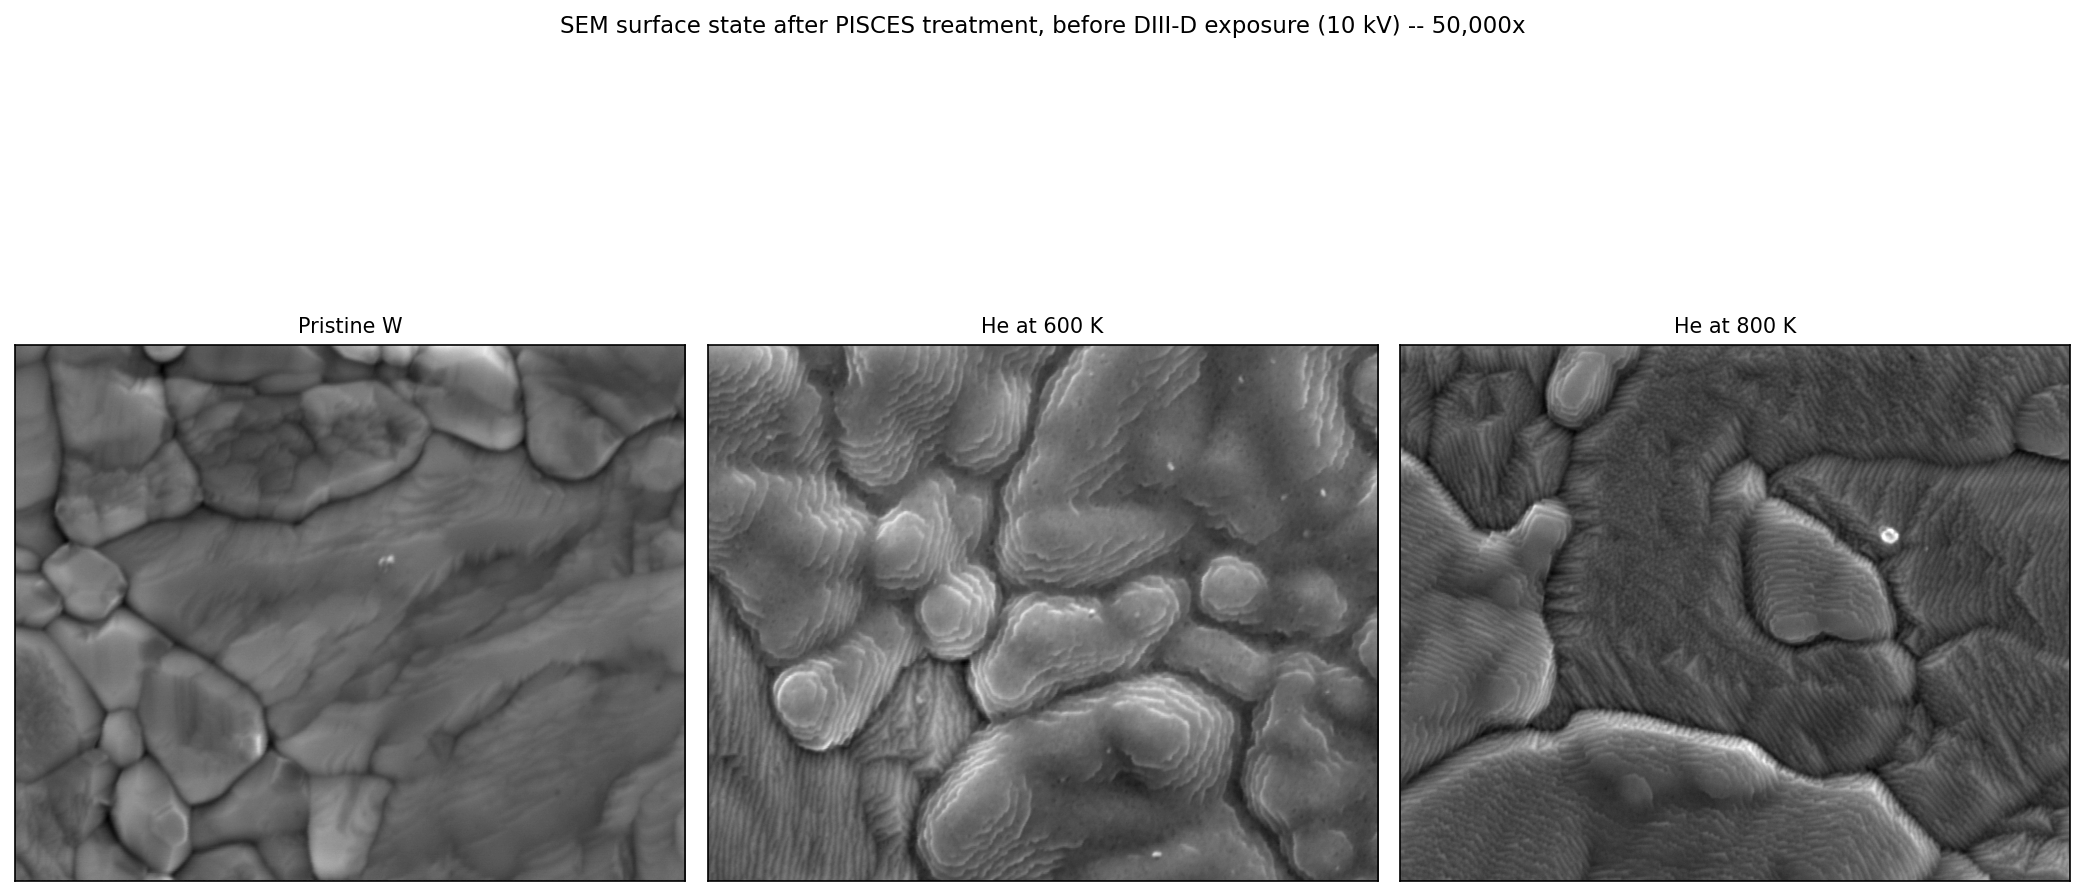

## Experimental limitations

- **No replication** : Every treatment cell contains one coupon. Instrument uncertainty can be propagated, but it does not measure coupon-to-coupon variability; the observed differences therefore cannot be cleanly separated from sample variability.
- **The helium treatments differed in more than temperature** : Both used 70 eV He and fluences near $10^{25}$ m$^{-2}$, but the 600 K treatment used $1.0\times10^{25}$ m$^{-2}$ over 4,260 s, while the 800 K treatment used $1.2\times10^{25}$ m$^{-2}$ over 480 s. Flux, duration, and temperature changed together, so the contrast cannot be attributed to temperature alone.
- **H- and L-mode results should not be pooled** : Coupons within each regime shared one DIII-D campaign, but the two regimes had different fluence, impact energy, heat flux, and exposure duration.
- **DIII-D coupon temperature was not measured** : Neither bulk nor surface sample temperature during the D exposure is available.
- **Methods are not interchangeable** : ERDA, NRA, and LAMS have different probing depths and spatial resolution. Their absolute numbers should not be compared as though one were a corrected version of another; the useful comparison is within each method against its same-regime control.

Overall, the data support a **condition-dependent helium effect** : moderate-temperature helium exposure can increase retained D, while the higher-temperature treatment tends to suppress deeper penetration and—under H-mode exposure—substantially reduce the total retained inventory.

## Data files

All reported values and calculations are available in the working folder:

- [`he_effect_summary.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/he_effect_summary.csv) — compact method-by-method effect sizes and control ratios.
- [`he_effect_d_retention_scalar.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/he_effect_d_retention_scalar.csv) — ERDA and NRA measurements, uncertainties, differences, and ratios.
- [`he_effect_lams_profiles.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/he_effect_lams_profiles.csv) — all depth-resolved LAMS values and same-depth control ratios.
- [`he_effect_lams_integrals.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/he_effect_lams_integrals.csv) — derived LAMS profile integrals and their calculation formula.
- [`he_effect_experimental_design.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/he_effect_experimental_design.csv) — treatment cells, exposure identifiers, and replication counts.
- [`he_effect_exposure_conditions.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/he_effect_exposure_conditions.csv) — PISCES and DIII-D exposure conditions.
- [`he_pre_exposure_sem_metrics.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/he_pre_exposure_sem_metrics.csv) — per-image matched-setting SEM texture measurements.
- [`he_pre_exposure_sem_metric_summary.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/he_pre_exposure_sem_metric_summary.csv) — sample-level SEM metric means and spreads.
- [`he_retention_discovery_snapshot.json`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/he_retention_discovery_snapshot.json) — complete lakehouse query snapshot, including observations, design, artifacts, and literature results.
- [`he_retention_evidence_compact.json`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/he_retention_evidence_compact.json) — condensed retention, exposure, imaging, and literature evidence.

## Reference

M.J. Baldwin and R.P. Doerner (2017) Hydrogen isotope transport across tungsten surfaces exposed to a fusion relevant He ion fluence. Nuclear Fusion 57 076031 doi:10.1088/1741-4326/aa70b1

In [1]:
%%ask
How does the presence of helium affect the retention of deuterium in tungsten?

## 2 — Does the answer depend on the measurement technique?

Three techniques measured retention on these coupons, and they do not all report
the same quantity or carry the same uncertainty.


I’ll compare the techniques on matched coupons, quantify reported and propagated uncertainties, and separate instrument uncertainty from unmeasured sample variability.

I’m reviewing how the tungsten observations encode technique, probing depth, and uncertainty before comparing them.

The comparison must keep ERDA, the two NRA depth bands, and LAMS separate; only ERDA carries reported standard deviations here.

I’m checking how the attached papers should be searched for technique limitations and uncertainty context.

I’m listing the existing text outputs so the live query can be cross-checked against the earlier extracted tables.

...

I’m running the uncertainty propagation and producing the method-comparison table and chart.

ERDA gives 3.5–8.1 combined-standard-deviation separations, but LAMS pointwise sigmas are typically 82–103% of values and NRA has no supplied uncertainties.

I’m verifying the final text tables so every quoted percentage and uncertainty matches the saved calculations.

The key synthesis is complete: H-mode’s direction is method-consistent, while L-mode reverses between near-surface and deeper-sensitive measurements.

**Bottom line** : The answer is strongly technique- and depth-dependent. For H-mode coupons, all three methods give the same qualitative direction—600 K helium pre-exposure increases the point estimate of retention, while 800 K helium pre-exposure decreases it. For L-mode coupons, ERDA and near-surface NRA indicate increased retention, but sub-surface NRA and depth-integrated LAMS indicate reduced deeper retention, so helium appears to redistribute deuterium toward the surface rather than increasing it uniformly.

## Technique-by-technique comparison

The table gives the change relative to the **no-helium coupon from the same DIII-D regime** . Methods are not averaged because the provider states that they differ in probing depth, spatial resolution, units, and setup-dependent uncertainty.

| DIII-D regime | Helium pre-exposure | ERDA total | NRA surface, 0–0.5 µm | NRA sub-surface, 0.5–3 µm | LAMS integral, 0.024–2.155 µm |
|---|---:|---:|---:|---:|---:|
| H-mode | 600 K | $+26.7\%\pm8.7\%$ | $+14.4\%$ | $+32.6\%$ | $+68.2\%\pm88.7\%$ |
| H-mode | 800 K | $-42.4\%\pm5.2\%$ | $-67.7\%$ | $-76.6\%$ | $-50.5\%\pm24.8\%$ |
| L-mode | 600 K | $+63.3\%\pm10.0\%$ | $+121.0\%$ | $-24.4\%$ | $-3.7\%\pm61.2\%$ |
| L-mode | 800 K | $+36.1\%\pm8.7\%$ | $+34.5\%$ | $-58.9\%$ | $-33.1\%\pm45.0\%$ |

**Uncertainty notation** :

- The ERDA uncertainties are propagated from the delivered treated-coupon and control-coupon standard deviations, assuming their measurement errors are independent.
- The NRA delivery contains **no uncertainty column** , so no uncertainty can be attached to those percentages from the supplied data.
- The LAMS uncertainties are an **analytical approximation** , not a provider-supplied uncertainty for the integral. They were propagated from the pointwise LAMS sigmas while assuming that the ten depth points are independent and that covariance and systematic errors are absent. Those assumptions are unlikely to capture the complete uncertainty budget.


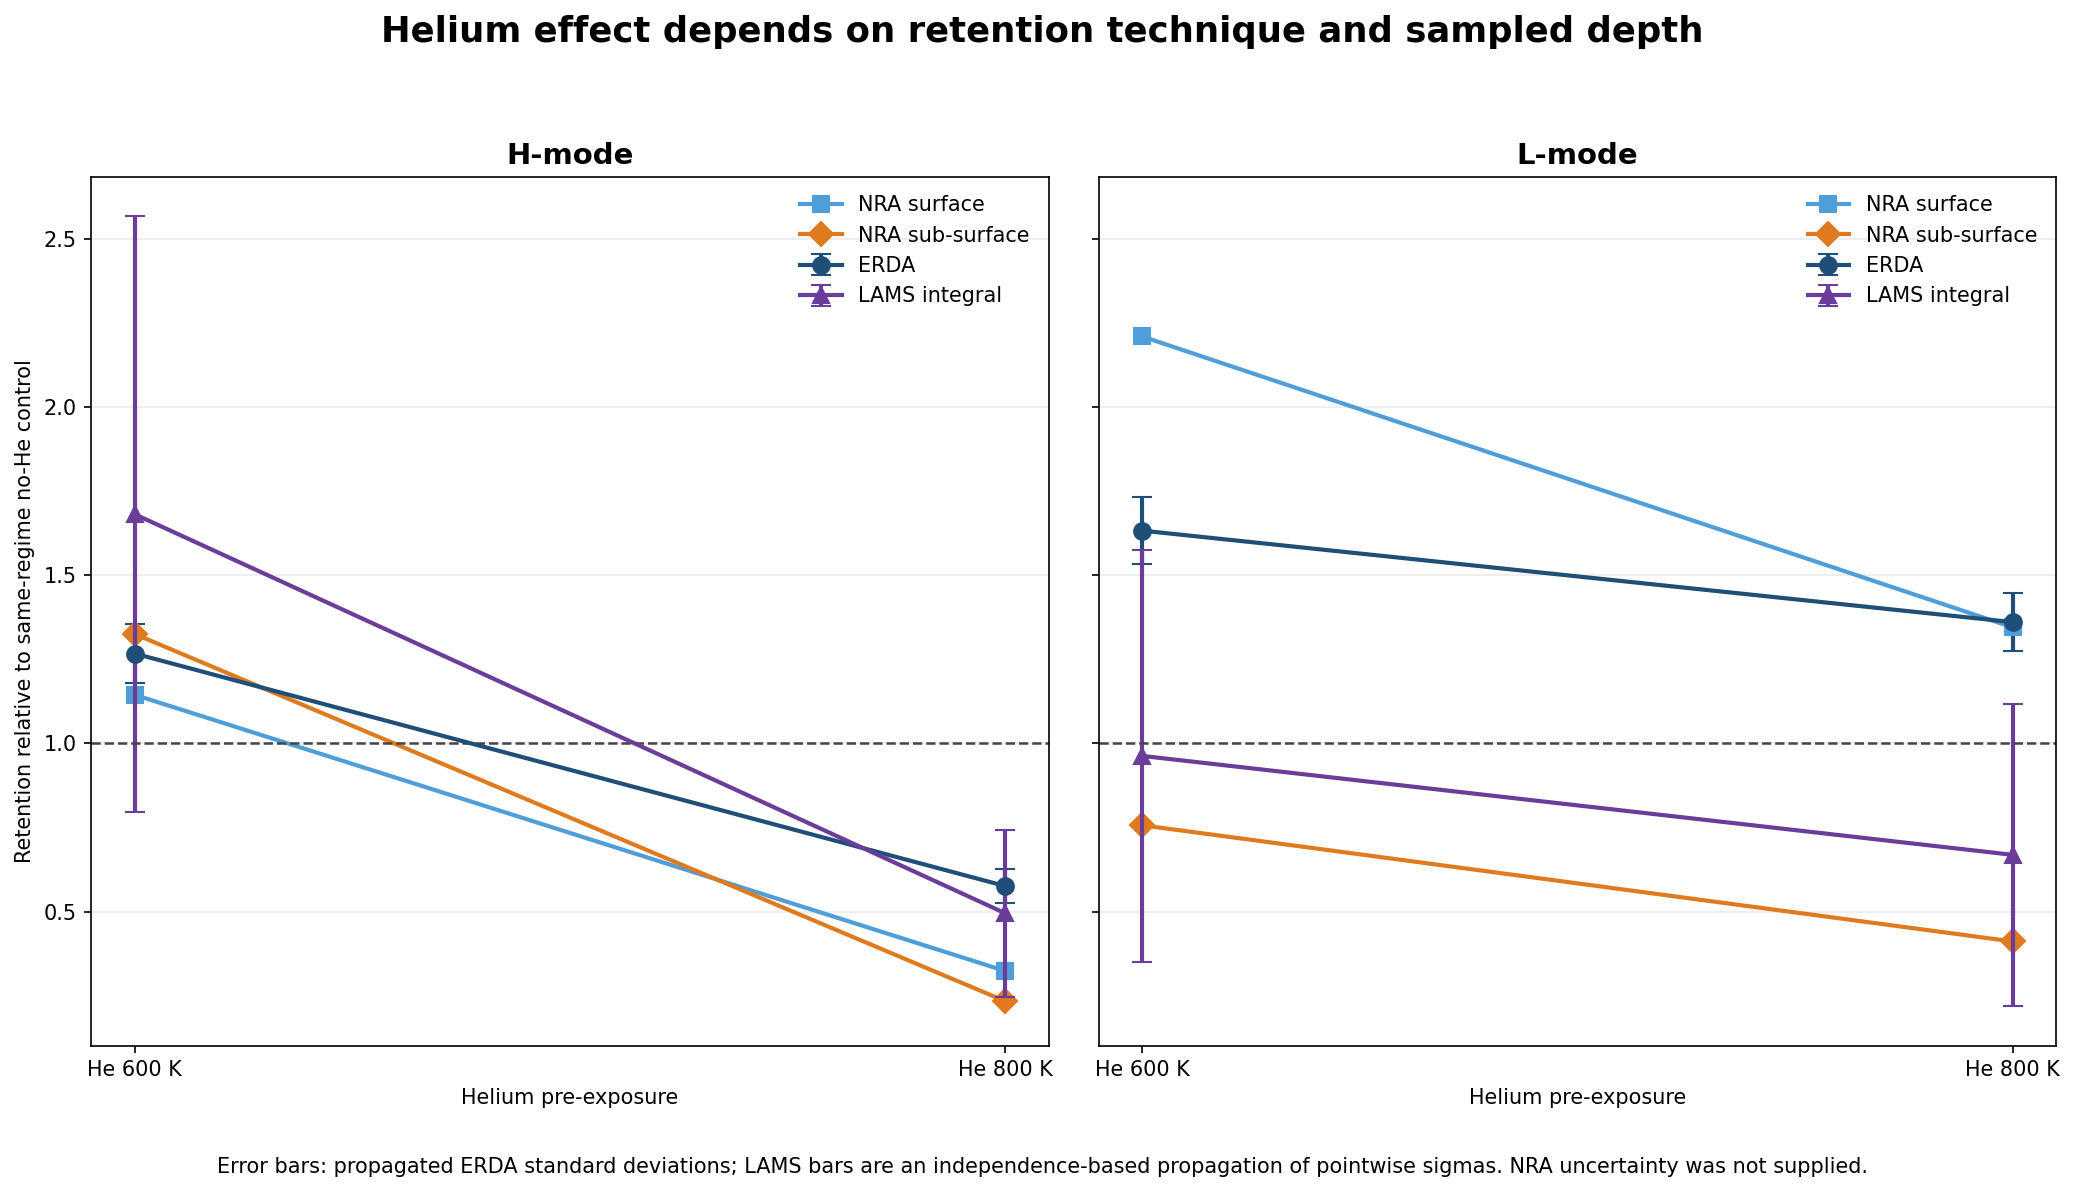

## What each technique says

### ERDA: a scalar total with relatively small reported standard deviations

ERDA gives one areal-density measurement per coupon. Its individual relative standard deviations range from approximately **3.8% to 7.2%** .

Under independent-error propagation, the helium-treated versus control differences are:

| Regime and treatment | Ratio to control | Difference divided by combined reported standard deviation |
|---|---:|---:|
| H-mode, He 600 K | $1.267\pm0.087$ | $+3.52$ |
| H-mode, He 800 K | $0.576\pm0.052$ | $-6.22$ |
| L-mode, He 600 K | $1.633\pm0.100$ | $+8.08$ |
| L-mode, He 800 K | $1.361\pm0.087$ | $+4.86$ |

Thus, the ERDA changes are large compared with the **reported ERDA measurement standard deviations** . This is good evidence that the numerical differences are not merely ERDA readout scatter under the propagation assumptions.

It is not, however, a statistical treatment-effect test. Each condition contains only one coupon, so those standard deviations do not include coupon-to-coupon variation.

### NRA: the answer changes with depth

NRA divides the inventory into two delivered depth bands:

- **Surface, 0–0.5 µm**
- **Sub-surface, 0.5–3 µm**

For H-mode, both bands agree in direction:

- At 600 K, helium increased the surface estimate by 14% and the sub-surface estimate by 33%.
- At 800 K, helium reduced the surface estimate by 68% and the sub-surface estimate by 77%.

For L-mode, the two bands give opposite answers:

- At 600 K, the surface inventory increased by 121%, but the sub-surface inventory decreased by 24%.
- At 800 K, the surface inventory increased by 35%, but the sub-surface inventory decreased by 59%.

That opposition is physically more informative than a single total: under L-mode exposure, helium appears to have shifted the retained deuterium toward the outer 0.5 µm while suppressing retention farther below the surface.

The delivered NRA workbook notes that the sub-surface D concentration was above an approximate 10 appm detection limit. That supports detection, but a detection limit is not an uncertainty estimate. Because no NRA error bars, standard deviations, or calibration uncertainty were supplied, the magnitudes—and even the certainty of the smaller changes—cannot be assessed quantitatively from this delivery.

### LAMS: rich depth information, but large pointwise sigmas

LAMS provides ten depth points from approximately 0.024 to 2.155 µm. The profiles are highly nonuniform:

- H-mode, 600 K: 8 of 10 point estimates are above the control and 2 are below.
- H-mode, 800 K: 1 of 10 is above and 9 are below.
- L-mode, 600 K: 6 of 10 are above and 4 are below.
- L-mode, 800 K: 2 of 10 are above and 8 are below.

The depth-integrated LAMS point estimates therefore summarize profiles that reverse locally; they should not be interpreted as uniform changes through the tungsten.

The pointwise LAMS sigmas are also large:

- Median relative sigma across a treatment profile ranges from approximately **82% to 103%** .
- Individual relative sigmas range from approximately **57% to 199%** .
- Of the 40 treated-versus-control depth comparisons, none differs from its control by at least two combined pointwise sigmas.
- Only one point—the H-mode 800 K comparison at 1.435 µm—exceeds one combined sigma, at approximately $-1.47$.

The approximate integrated LAMS uncertainties reflect this:

- H-mode, 600 K: ratio $1.68\pm0.89$.
- H-mode, 800 K: ratio $0.50\pm0.25$.
- L-mode, 600 K: ratio $0.96\pm0.61$.
- L-mode, 800 K: ratio $0.67\pm0.45$.

These error estimates are best regarded as a sensitivity calculation. Adjacent depth measurements may share calibration, normalization, ablation, or fitting errors, but the delivery provides no covariance matrix. Treating the depths as independent can therefore either understate or overstate the true integrated uncertainty.

The absolute LAMS integral should also not be compared directly with the absolute ERDA or NRA areal densities. The integral was derived from APPM profiles using the tungsten atomic density and sampled depth range; it is useful for **within-LAMS treated/control ratios** , not as a replacement for either scalar method.

## How much confidence should be placed in the overall conclusion?

### Relatively well supported

1. **H-mode direction across techniques** : Every point estimate says that 600 K helium raises retention and 800 K helium lowers it. ERDA supports both directions with differences several times larger than its reported measurement standard deviations.
2. **L-mode depth redistribution** : ERDA and surface NRA increase while sub-surface NRA and integrated LAMS decrease. The agreement between the two deeper-sensitive summaries supports a shallower distribution, even though NRA lacks uncertainties and LAMS has large ones.
3. **The methods should remain separate** : The disagreement is not evidence that one instrument is wrong. According to the provider, the methods probe different depths and spatial scales and should neither be ranked nor averaged.

### Not established by this dataset

1. **Population-level treatment uncertainty** : Every experimental cell contains only one coupon. There is no replication from which to estimate tungsten coupon variability, surface heterogeneity between coupons, or repeatability of the full treatment-and-measurement sequence.
2. **NRA statistical certainty** : No uncertainty values were supplied. A 121% increase is numerically large, but this delivery cannot attach a confidence interval to it.
3. **A definitive integrated LAMS effect** : The pointwise sigmas are comparable to the measured concentrations, and the integrated uncertainties depend on an unverified independence assumption.
4. **A pure temperature effect** : The 600 K and 800 K PISCES exposures also differed in fluence, flux, and duration. Their contrast cannot be assigned to temperature alone.
5. **Effects of DIII-D coupon temperature** : Neither bulk nor surface coupon temperature was measured during the DIII-D exposure.

## Overall interpretation

The strongest defensible conclusion is not simply “helium raises” or “helium lowers” deuterium retention. It is:

- **Under H-mode exposure** , the treatment direction is consistent across techniques: 600 K helium pre-exposure increases the measured inventory, while 800 K helium pre-exposure decreases it.
- **Under L-mode exposure** , the conclusion depends on probing depth: the outer 0.5 µm becomes richer in deuterium, while measurements extending deeper into the tungsten generally show depletion.
- **ERDA provides the tightest reported numerical uncertainties in this delivery** , but that does not make it universally preferable; it answers a different depth-integrated question.
- **NRA supplies the clearest depth-band contrast but no uncertainty estimates** .
- **LAMS gives the most detailed profile structure, but its delivered pointwise sigmas are large** , making fine depth-by-depth differences uncertain.

## Data files

- [`retention_technique_uncertainty_summary.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/retention_technique_uncertainty_summary.csv) — technique-specific ratios, percentage changes, propagated uncertainties, and treated-control difference statistics.
- [`lams_depth_uncertainty_comparisons.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/lams_depth_uncertainty_comparisons.csv) — all 40 LAMS treated-control depth comparisons, pointwise sigmas, relative uncertainties, and standardized differences.
- [`retention_technique_uncertainty_live.json`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/retention_technique_uncertainty_live.json) — authoritative live lakehouse response containing ERDA, NRA, and LAMS measurements, experimental design, provider guidance, and the attached-literature search.
- [`retention_method_document_hits.json`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/retention_method_document_hits.json) — delivered-document matches for the instrument names, depth information, uncertainty terms, and analyst notes.

In [2]:
%%ask
How does the answer depend on the retention measurement technique? Can you 
comment on the uncertainty in these measurements?

## 3 — Retention against the DIII-D plasma condition

The coupons were exposed in two confinement regimes. This asks for the effect of
that difference, in total and with depth, with the method dependence from the
previous question carried through.


I’ll compare L-mode with H-mode within each helium-treatment condition, preserving each technique’s depth sensitivity and reported uncertainty.

I’m reading the tungsten sample workflow to identify the authoritative tables, joins, and measurement caveats.

The workflow identifies ERDA, NRA, and LAMS as distinct measurements; I’ll now review how the attached papers should be searched and interpreted.

The comparison must use live observations, delivery notes, experimental design, recorded plasma conditions, and a scoped literature search; the workflow review is complete.

I’m listing prior tabular outputs so the live query can be cross-checked without opening any rendered images.

...

I’m writing an audit that independently recomputes stored ratios, checks row counts and depth grids, and verifies chart files exist without opening any images.

I’m running the audit to validate the saved numerical tables and confirm all figures were written successfully.

The audit passed: all 15 technique summaries, 30 LAMS depth comparisons, and seven plasma-condition contrasts reproduce exactly, with no image files opened.

I’m finalizing the report with raw L/H changes, depth structure, method-specific uncertainty, and the multi-parameter nature of the campaign comparison.

**Bottom line** : Changing from the recorded H-mode campaign to the recorded L-mode campaign increased ERDA total D retention by **27% without helium pre-exposure, 63% after 600 K He pre-exposure, and 199% after 800 K He pre-exposure** . The size—and for the 600 K pair, even the depth-integrated conclusion—depends strongly on technique: NRA gives increases of **27–354%** over its combined 0–3 µm bands, whereas the integrated LAMS profiles range from **essentially no change to a 136% increase** and exhibit strong depth-to-depth variation.

All changes below are calculated as

$$
100\left(\frac{\text{L-mode value}}{\text{H-mode value}}-1\right),
$$

comparing coupons with the **same helium pre-treatment** .

## The DIII-D conditions that changed

This was not a controlled change in plasma regime alone. The L- and H-mode coupons were exposed in separate shot sets, and several recorded conditions changed simultaneously.

| Recorded DIII-D condition | H-mode | L-mode | L relative to H |
|---|---:|---:|---:|
| Average heat flux | 0.72 MW m$^{-2}$ | 0.47 MW m$^{-2}$ | −34.7% |
| Average particle fluence | $6.7\times10^{22}$ m$^{-2}$ | $7.8\times10^{22}$ m$^{-2}$ | +16.4% |
| Average particle flux | $4.5\times10^{21}$ m$^{-2}$ s$^{-1}$ | $7.5\times10^{21}$ m$^{-2}$ s$^{-1}$ | +66.7% |
| Exposure duration | 12.5 s | 10.0 s | −20.0% |
| Impact energy | 150 eV | 175 eV | +16.7% |
| Recorded $n_e$ | $5.76\times10^{18}$ m$^{-3}$ | $7.35\times10^{18}$ m$^{-3}$ | +27.6% |
| Recorded $T_e$ | 27.9 eV | 40.8 eV | +46.2% |

The H-mode campaign comprised shots 185258–185260 and 185265–185266; the L-mode campaign comprised shots 185261–185264. Sample temperature during either DIII-D exposure was not measured.

Thus, the results quantify the difference between these two **recorded exposure campaigns** , not an isolated causal effect of the L/H confinement-mode label.


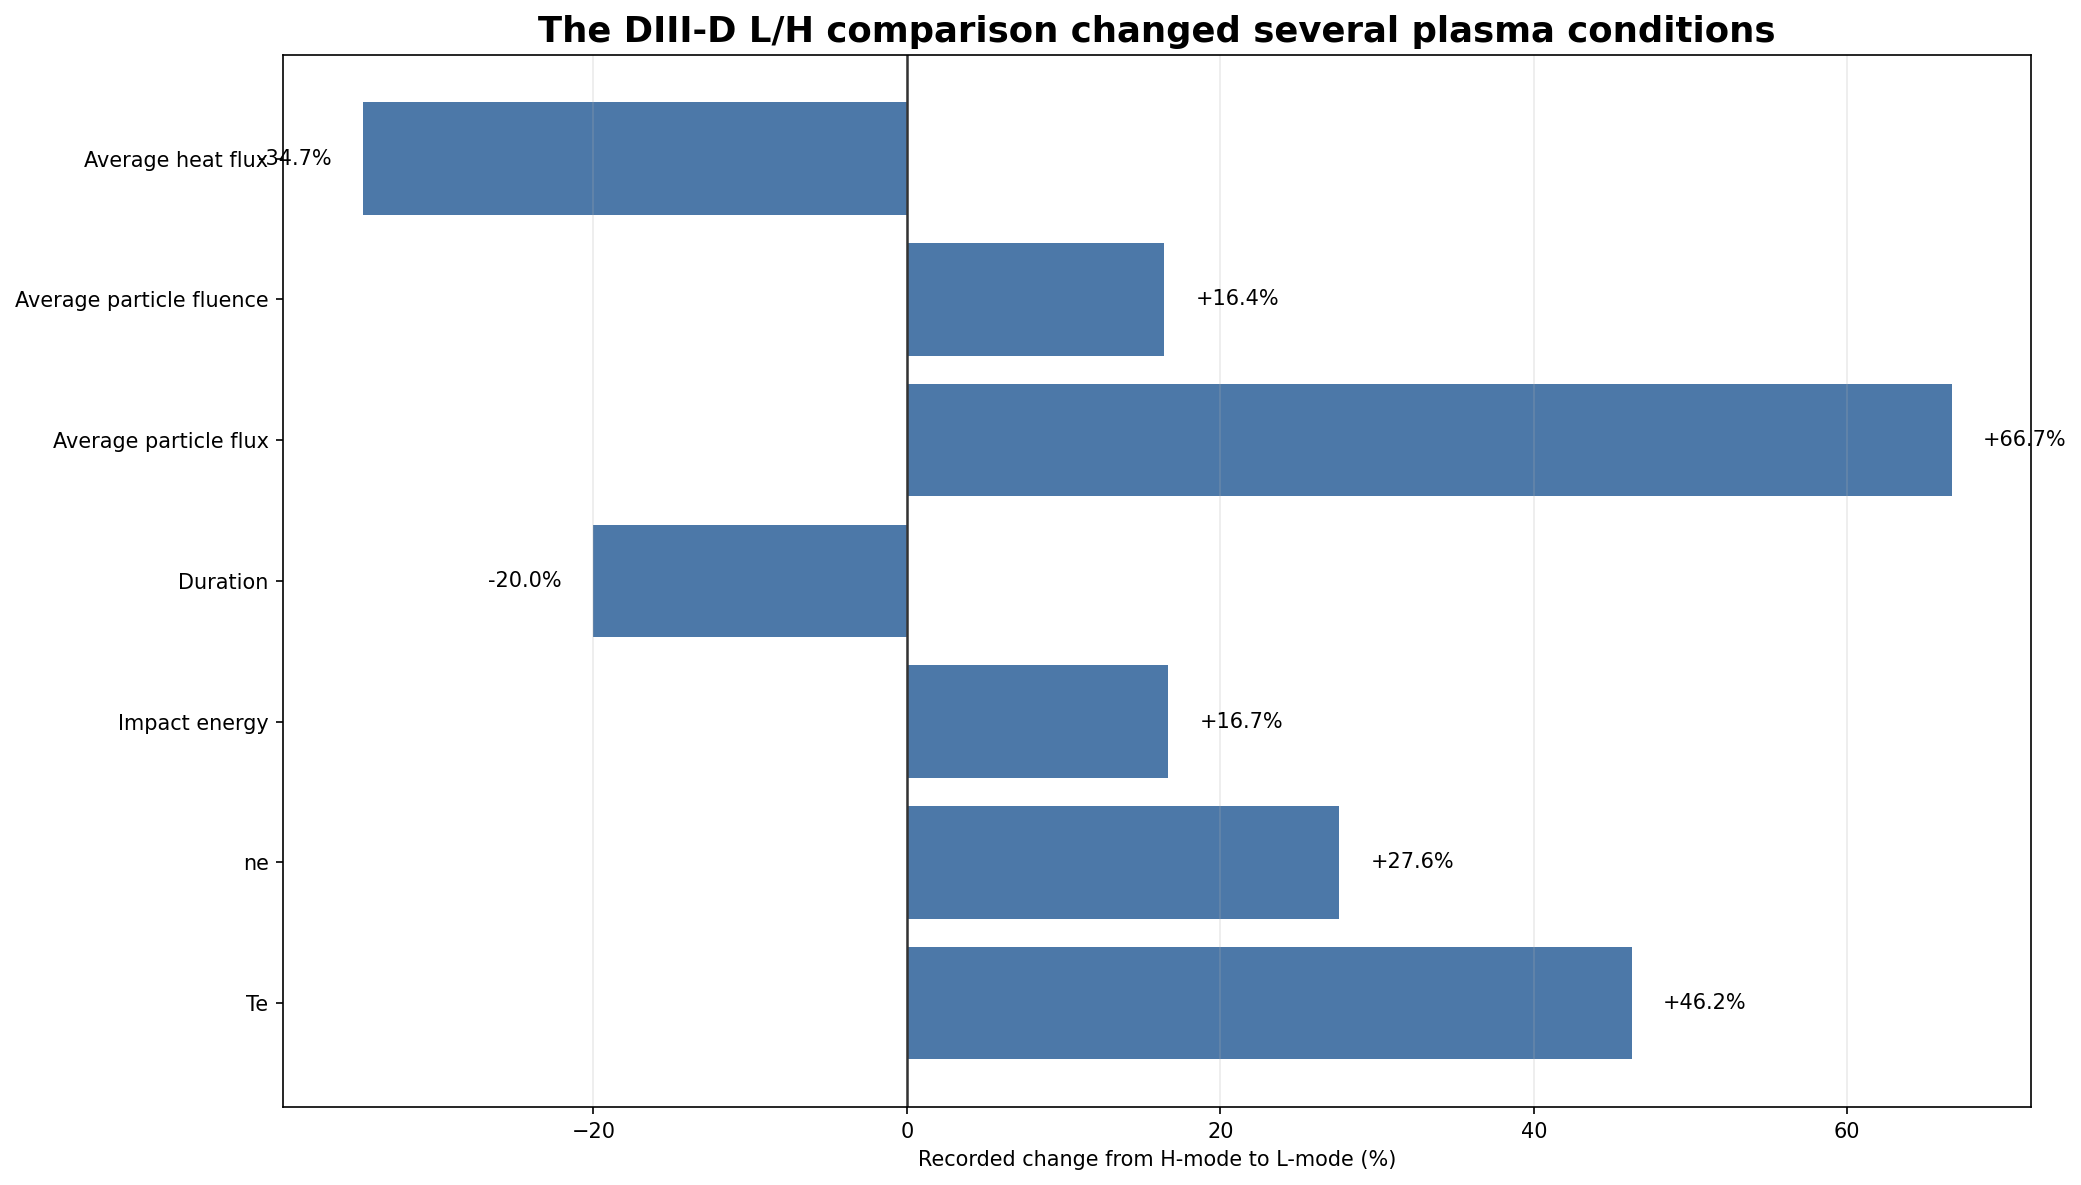

## Total or depth-integrated D retention

### ERDA delivered total

| Helium pre-treatment | H-mode total | L-mode total | L/H ratio | Change from H to L |
|---|---:|---:|---:|---:|
| No He | $1.16\times10^{15}$ | $1.47\times10^{15}$ | $1.267\pm0.092$ | $+26.7\%\pm9.2$ percentage points |
| He at 600 K | $1.47\times10^{15}$ | $2.40\times10^{15}$ | $1.633\pm0.092$ | $+63.3\%\pm9.2$ percentage points |
| He at 800 K | $6.68\times10^{14}$ | $2.00\times10^{15}$ | $2.994\pm0.248$ | $+199.4\%\pm24.8$ percentage points |

ERDA values are in D atoms cm$^{-2}$. Its result is unambiguous in direction: **L-mode coupons retained more D for all three helium histories** , and the L/H contrast was greatest after the 800 K helium treatment.

The stated uncertainties were propagated from the ERDA standard deviations supplied for both coupons, assuming independent measurement errors. The L-minus-H differences equal 3.26, 8.49, and 13.93 combined reported standard deviations for the no-He, 600 K, and 800 K pairs, respectively. Those are comparisons with the supplied **instrument-level standard deviations** , not treatment-effect significance tests, because there was only one coupon in each cell.

### NRA summed over its two delivered bands

The two non-overlapping NRA bands—0–0.5 and 0.5–3 µm—can be summed to describe the measured 0–3 µm inventory:

| Helium pre-treatment | H-mode 0–3 µm sum | L-mode 0–3 µm sum | L/H ratio | Change from H to L |
|---|---:|---:|---:|---:|
| No He | $2.098\times10^{15}$ | $2.657\times10^{15}$ | 1.266 | +26.6% |
| He at 600 K | $2.455\times10^{15}$ | $4.917\times10^{15}$ | 2.003 | +100.3% |
| He at 800 K | $6.516\times10^{14}$ | $2.960\times10^{15}$ | 4.543 | +354.3% |

These values are also in D atoms cm$^{-2}$. NRA agrees with ERDA that L-mode produced more measured D in every matched pair, but it gives substantially larger L/H effects for the helium-treated coupons:

- **600 K He** : +100% by summed NRA versus +63% by ERDA.
- **800 K He** : +354% by summed NRA versus +199% by ERDA.

No NRA uncertainty values were supplied, so confidence intervals cannot be calculated for these differences from the delivered data.

### Integrated LAMS profiles

LAMS reports APPM as a function of depth rather than a provider-supplied total. Trapezoidal integration over the common sampled range, 0.024–2.155 µm, gives:

| Helium pre-treatment | L/H integrated-profile ratio | Change from H to L |
|---|---:|---:|
| No He | $1.747\pm1.095$ | $+74.7\%\pm109.5$ percentage points |
| He at 600 K | $1.0001\pm0.537$ | $+0.006\%\pm53.7$ percentage points |
| He at 800 K | $2.359\pm1.315$ | $+135.9\%\pm131.5$ percentage points |

These are **derived profile integrals** , not delivered LAMS totals. The ratio is independent of the constant used to convert APPM-depth to areal density.

The principal technique disagreement occurs for the **600 K He pair** :

- ERDA: L-mode is 63% higher.
- Summed NRA: L-mode is 100% higher.
- Integrated LAMS: essentially unchanged.

That LAMS result arises because large increases at a few shallow depths are offset by decreases through much of the rest of the sampled profile.


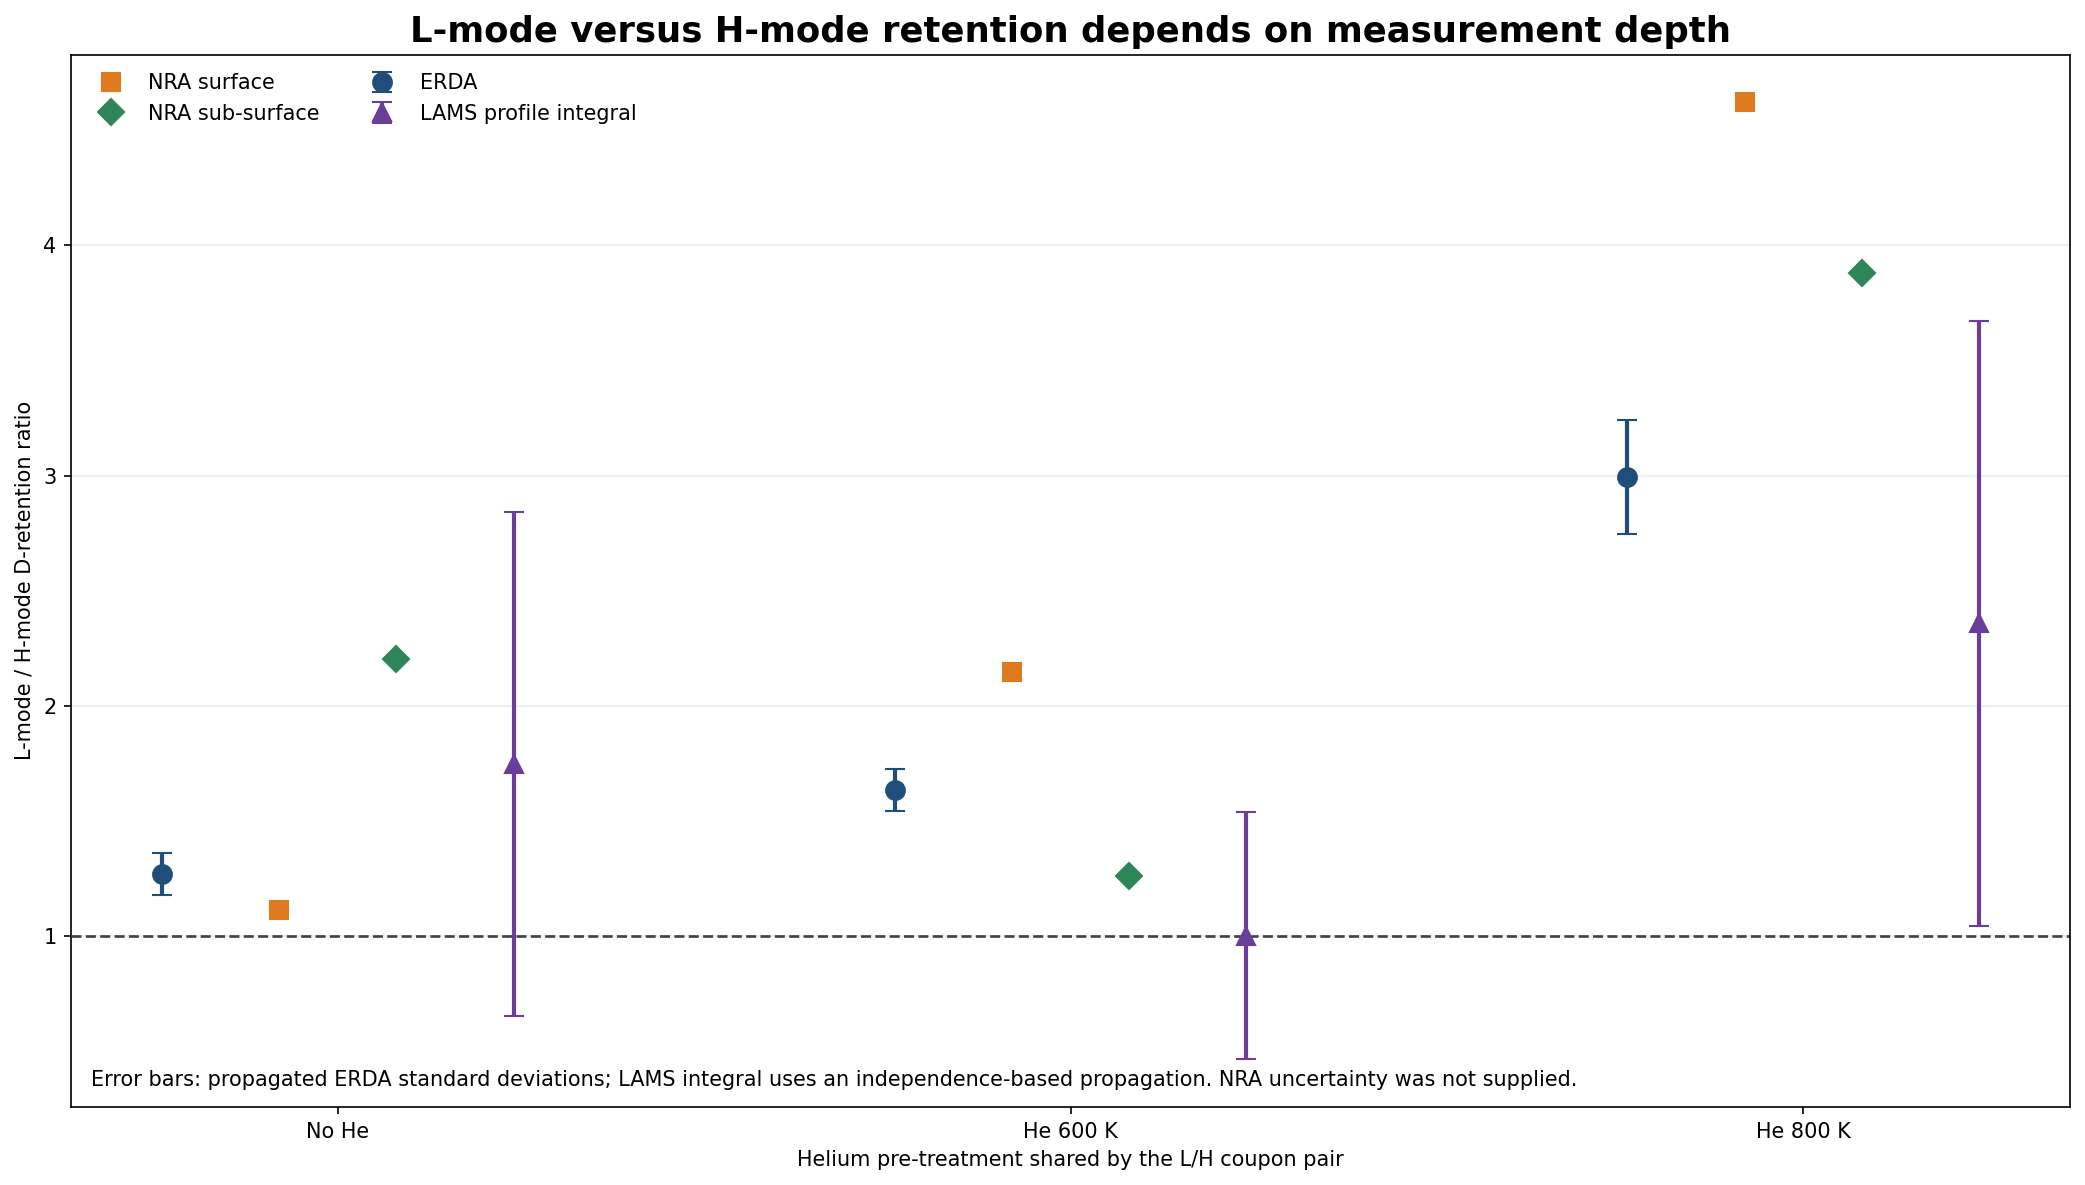

## Depth dependence

### NRA depth bands

| Helium pre-treatment | NRA band | H-mode | L-mode | Change from H to L |
|---|---|---:|---:|---:|
| No He | Surface, 0–0.5 µm | $1.80\times10^{15}$ | $2.00\times10^{15}$ | +11.1% |
| No He | Sub-surface, 0.5–3 µm | $2.98\times10^{14}$ | $6.57\times10^{14}$ | +120.5% |
| He at 600 K | Surface, 0–0.5 µm | $2.06\times10^{15}$ | $4.42\times10^{15}$ | +114.6% |
| He at 600 K | Sub-surface, 0.5–3 µm | $3.95\times10^{14}$ | $4.97\times10^{14}$ | +25.8% |
| He at 800 K | Surface, 0–0.5 µm | $5.82\times10^{14}$ | $2.69\times10^{15}$ | +362.2% |
| He at 800 K | Sub-surface, 0.5–3 µm | $6.96\times10^{13}$ | $2.70\times10^{14}$ | +287.9% |

NRA therefore indicates that the L/H effect changes with both depth and helium history:

- **No helium** : the L-mode increase is small in the surface band but much larger below 0.5 µm.
- **600 K helium** : the pattern reverses—the dominant increase is in the outer 0.5 µm.
- **800 K helium** : L-mode retention is several times higher in both bands.

### LAMS depth profile

The following are pointwise percentage changes from H to L at each common LAMS depth:

| Depth (µm) | No He | He at 600 K | He at 800 K |
|---:|---:|---:|---:|
| 0.024 | +410.2% | +259.3% | +236.5% |
| 0.068 | −58.4% | −51.2% | +245.1% |
| 0.156 | +409.4% | −12.3% | +81.4% |
| 0.314 | −42.1% | −8.6% | +9.4% |
| 0.532 | +66.3% | +42.0% | +84.0% |
| 0.797 | +114.5% | −40.6% | +86.8% |
| 1.102 | +172.5% | −2.3% | +48.2% |
| 1.435 | −41.1% | −5.9% | +203.2% |
| 1.791 | +93.2% | −2.3% | +140.6% |
| 2.155 | −12.3% | +0.04% | +75.3% |

The profiles separate into three patterns:

1. **No-He pair** : L-mode is higher at 6 of 10 depths, but the sign alternates. Point estimates range from a 58% decrease to a 410% increase.
2. **600 K He pair** : L-mode is higher at only 3 of 10 depths. The very shallow increase at 0.024 µm and the increase near 0.532 µm offset modest decreases elsewhere, leaving the integrated LAMS profiles essentially equal.
3. **800 K He pair** : L-mode is higher at all 10 sampled depths. The point-estimate increases range from 9% to 245%, making this the most internally consistent depth-profile result.


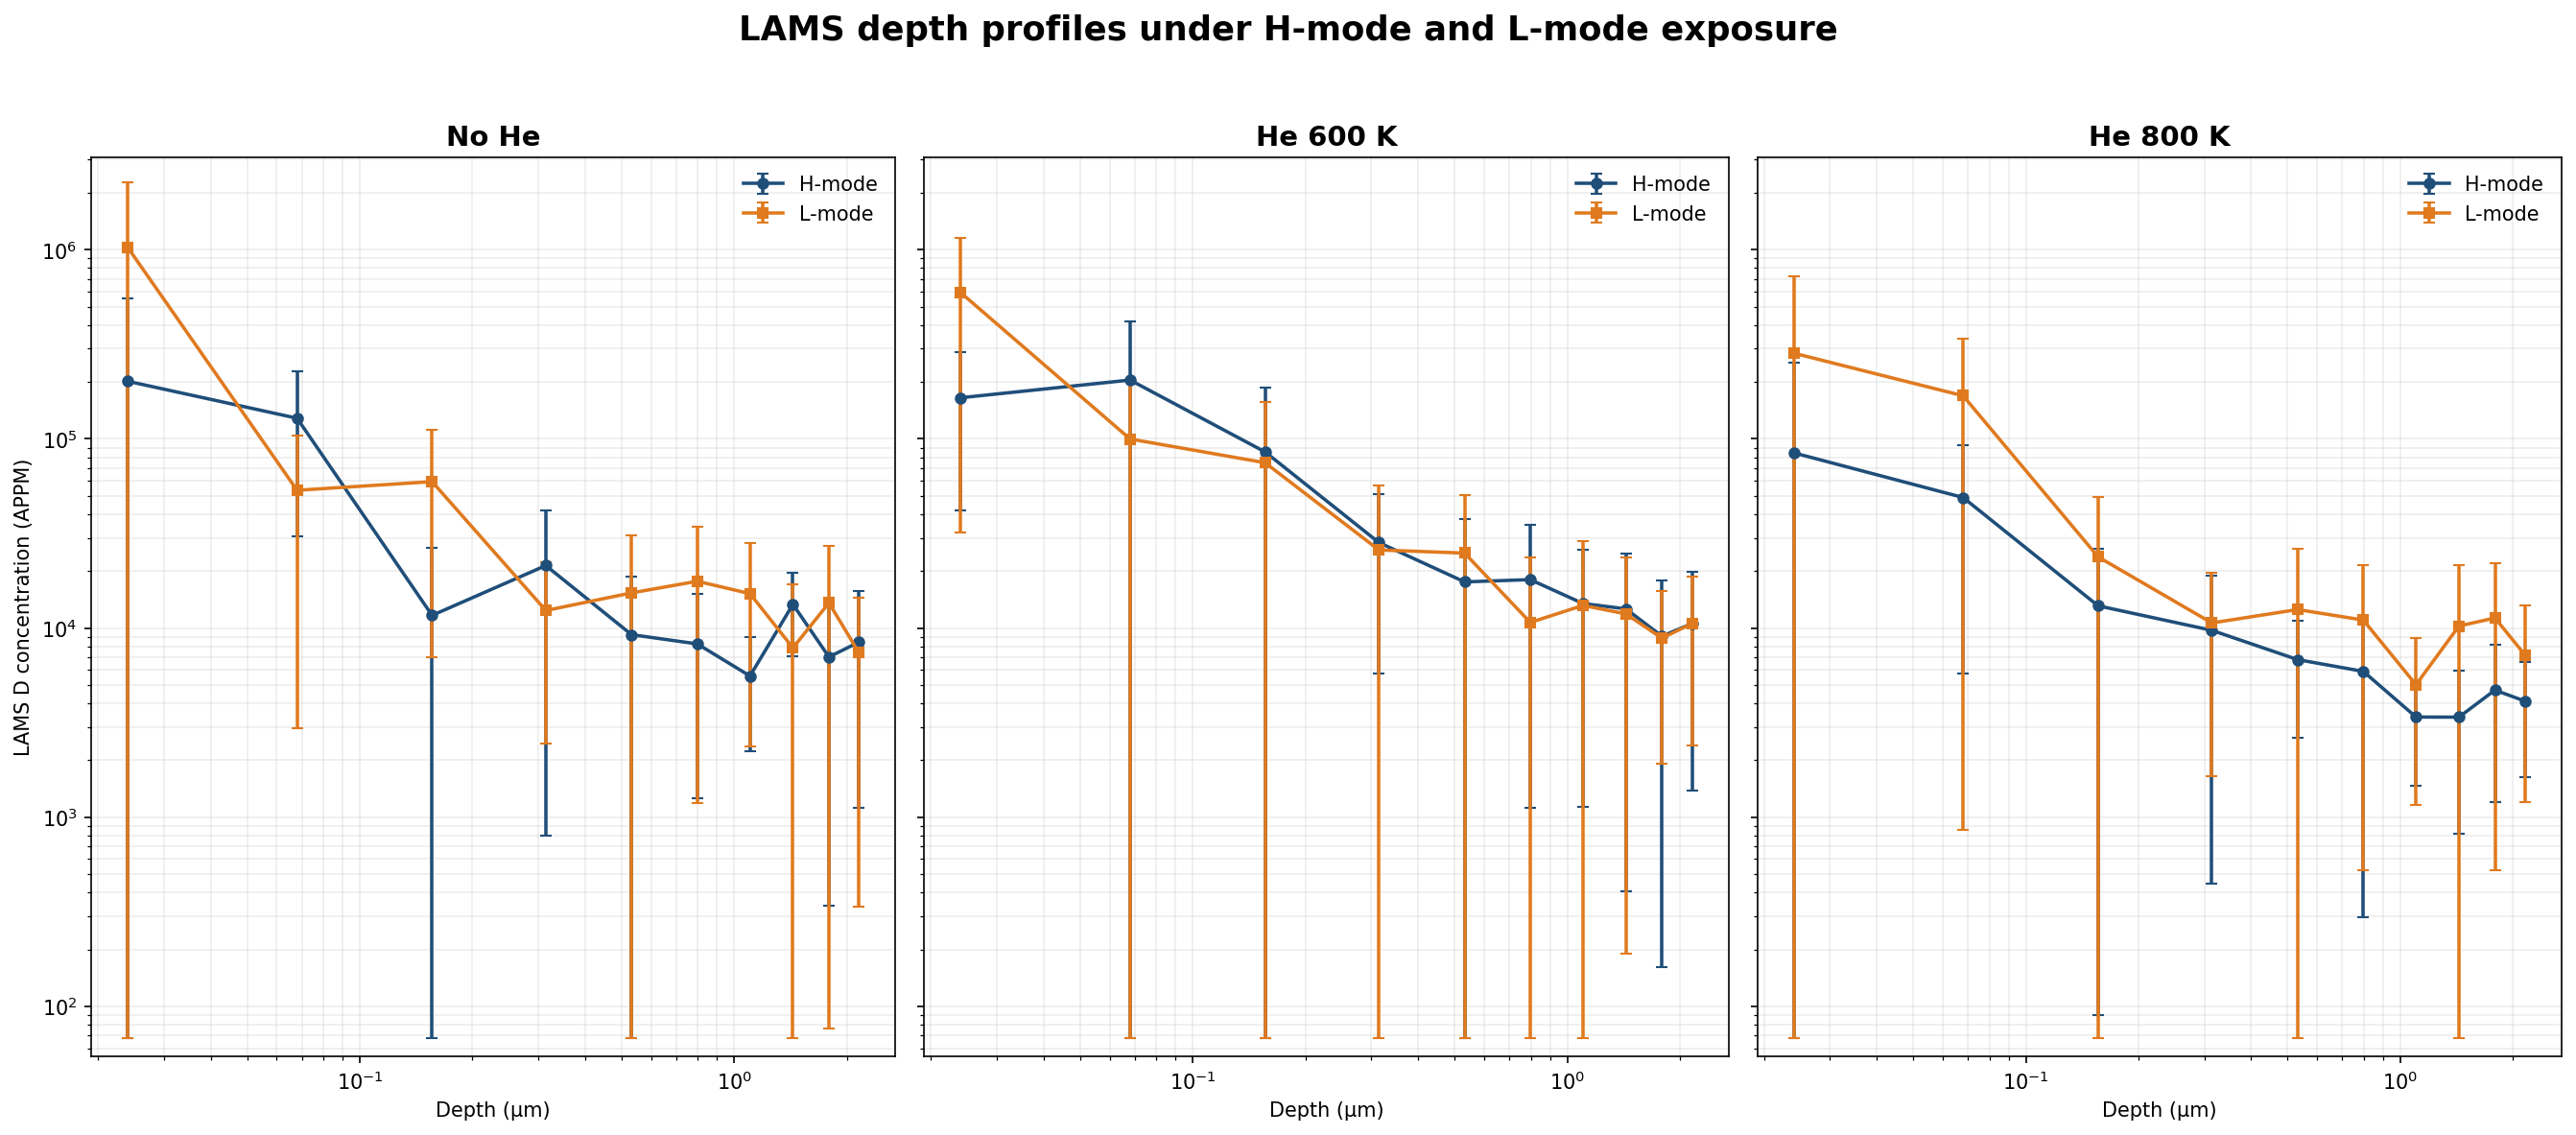

## Dependence on measurement technique

The techniques should not be averaged or treated as interchangeable. The provider states that they differ in probing depth, spatial resolution, and setup-dependent uncertainty.

### No helium pre-exposure

ERDA and summed NRA agree closely on the integrated change: both give approximately **+27%** in L-mode. LAMS gives a larger integrated point estimate of **+75%** , but its depth profile changes sign four times relative to the H-mode profile and its uncertainty is large.

The NRA bands reveal why a scalar total is incomplete: the surface change is only +11%, whereas the 0.5–3 µm band increases by 120%.

### 600 K helium pre-exposure

This is where the answer depends most strongly on technique:

- ERDA total: +63%.
- NRA 0–3 µm sum: +100%.
- NRA surface band: +115%.
- NRA sub-surface band: +26%.
- LAMS profile integral: approximately 0%.

Thus, ERDA and NRA indicate more retained D in the L-mode coupon, particularly near the surface, but LAMS indicates redistribution with little net change over its sampled profile. It would be misleading to collapse these measurements into one average “L-mode effect.”

### 800 K helium pre-exposure

Every technique gives the same direction:

- ERDA total: +199%.
- NRA 0–3 µm sum: +354%.
- NRA surface band: +362%.
- NRA sub-surface band: +288%.
- LAMS profile integral: +136%.
- LAMS point estimates: higher in L-mode at all 10 depths.

The magnitude still varies substantially by technique, but the qualitative conclusion—much greater D retention after the L-mode campaign—is consistent across their different depth sensitivities.

## Measurement uncertainty and experimental limits

### ERDA

ERDA is the only scalar method in this delivery with supplied standard deviations. Propagating them shows that all three L/H differences are large compared with the reported ERDA measurement scatter.

However, the propagated errors do **not** include:

- coupon-to-coupon tungsten variability;
- differences in initial surface condition between coupons;
- variability in the helium treatment;
- spatial heterogeneity not captured by the measurement;
- uncertainty from using different DIII-D shot sets;
- covariance or systematic calibration errors.

### NRA

No NRA standard deviations, error bars, or calibration uncertainties were supplied. The numerical differences can be reported, but their statistical uncertainty cannot be reconstructed from this dataset. The absence of an uncertainty column is neither evidence of high precision nor evidence of poor precision.

### LAMS

The delivered pointwise LAMS sigmas are large relative to many of the L/H differences:

- None of the 30 matched-depth L/H comparisons reaches one combined pointwise sigma.
- The largest absolute standardized pointwise difference is 0.88 combined sigma.
- The approximate integrated differences are 0.77, effectively 0, and 1.26 combined propagated sigmas for no He, 600 K He, and 800 K He, respectively.

The plotted and tabulated integral uncertainties assume independent errors among the ten depths. Adjacent depth points may instead share calibration, normalization, ablation, or fitting errors. Because no covariance matrix was supplied, the integrated LAMS errors are sensitivity estimates rather than complete uncertainty intervals.

### Experimental replication

Every L/H-treatment combination contains **one coupon** . Therefore, even an instrument difference many standard deviations from zero cannot establish a population-level plasma-regime effect. Instrument repeatability and experimental replication answer different questions, and this design supplies only the former for ERDA and pointwise LAMS.

## Overall conclusion

The most defensible interpretation is:

- The recorded **L-mode campaign generally produced more total D retention** than the recorded H-mode campaign.
- The ERDA increase grows from **27% without helium** to **63% after 600 K He** and **199% after 800 K He** .
- The **800 K He comparison is directionally consistent across every technique and every LAMS depth** .
- The **600 K He comparison is technique-dependent** : ERDA and NRA increase, especially near the surface, while the integrated LAMS profile is essentially unchanged.
- These differences cannot be attributed to confinement mode alone because particle fluence, particle flux, heat flux, impact energy, duration, $n_e$, and $T_e$ all changed between the two campaigns.

## Data files

- [`lh_mode_retention_summary.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/lh_mode_retention_summary.csv) — ERDA totals, NRA depth bands and 0–3 µm sums, LAMS integrals, L/H ratios, propagated uncertainties, and standardized differences.
- [`lh_mode_lams_depth_comparison.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/lh_mode_lams_depth_comparison.csv) — all 30 matched-depth LAMS comparisons with H- and L-mode values, sigmas, ratios, and percentage changes.
- [`lh_mode_exposure_conditions.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/lh_mode_exposure_conditions.csv) — recorded H- and L-mode campaign conditions and their percentage differences.
- [`lh_mode_retention_live.json`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/lh_mode_retention_live.json) — complete live lakehouse response containing the measurements, design cells, exposure records, provider guidance, and scoped literature results.

In [3]:
%%ask
Quantify changes in D retention with changes in DIII-D plasma conditions 
(L vs. H mode). Include both changes in the total D retention measured 
as well as D retention as a function of depth. As done previously, comment 
on differences in the answer based on the retention measurement technique 
that was used. 

## 4 — What this does not establish

A closing question about the limits of the dataset rather than its contents.


I’ll synthesize the delivered retention evidence, separate supported findings from causal overclaims, and identify measurements that would resolve the main ambiguities.

I’m inspecting the tungsten materials interface and its retained query guidance before retrieving the sample evidence.

I’m reading the materials query specification to retrieve the authoritative observations, design constraints, and measurement caveats.

I’m reviewing the attached-literature search interface because the needed follow-up measurements must be grounded in published experimental practice.

The measurement model is clear: all methods, provider notes, experimental cells, treatment evidence, and attached literature must be considered together.

...

I’m running the synthesis calculations and saving the numerical evidence, uncertainty limits, and claim boundaries as checkable tables.

The calculations reproduce the earlier technique-dependent pattern; I’m checking the saved tables before interpreting them.

The evidence hierarchy is now explicit: robust coupon-specific patterns, technique-dependent depth effects, but no replication, no isolated variables, and no direct post-exposure mechanism measurement.

I’m completing the final audit: all quoted values trace to the live delivery, methods remain separate, and no image file was read.

**Bottom line** : Collectively, these samples support a **condition-dependent and depth-dependent association** between helium pre-exposure, DIII-D plasma conditions, and retained deuterium—not a single monotonic “helium increases” or “helium decreases” effect. The strongest common pattern is that the 600 K and 800 K helium treatments behave differently, while the L-mode data indicate near-surface enrichment can occur at the same time as deeper depletion. The dataset is not sufficient to prove a population-level treatment effect, isolate confinement mode or helium-treatment temperature as the cause, or demonstrate that a helium-nanobubble permeation barrier produced the observations.

## What the measurements collectively support

Percentages below compare each helium-pre-exposed coupon with the no-helium coupon from the **same DIII-D campaign** . The LAMS values are trapezoidal integrals over the sampled 0.024–2.155 µm profile, not provider-supplied totals.

| DIII-D campaign | He treatment | ERDA scalar areal density | NRA, 0–0.5 µm | NRA, 0.5–3 µm | Integrated LAMS profile |
|---|---:|---:|---:|---:|---:|
| H-mode | 600 K | +27% | +14% | +33% | +68% |
| H-mode | 800 K | −42% | −68% | −77% | −50% |
| L-mode | 600 K | +63% | +121% | −24% | −4% |
| L-mode | 800 K | +36% | +35% | −59% | −33% |

### 1. The response depends on the helium-treatment condition

For the H-mode coupons, all three techniques agree in direction:

- The 600 K helium treatment is associated with **more measured D** .
- The 800 K treatment is associated with **less measured D** .

This sign agreement across methods is stronger evidence than any one measurement alone. It supports the statement that these two helium treatments left the tungsten in materially different states that affected subsequent D retention.

It does **not** show that temperature itself caused the difference. The 600 K and 800 K PISCES treatments also differed in particle fluence, flux, and exposure duration, so “helium-treatment condition” is the justified causal unit—not temperature in isolation.

### 2. Under L-mode exposure, helium is associated with a shallower D distribution

For both L-mode helium treatments:

- ERDA’s scalar areal density increases.
- NRA’s 0–0.5 µm band increases.
- NRA’s 0.5–3 µm band decreases.
- The LAMS profile integral is unchanged or lower.

That combination supports **depth redistribution toward the near surface** more strongly than it supports a uniform increase in retention. In particular:

- At 600 K, surface NRA rises 121%, while sub-surface NRA falls 24% and the integrated LAMS profile changes by only −4%.
- At 800 K, surface NRA rises 35%, while sub-surface NRA falls 59% and the LAMS integral falls 33%.

The measurements therefore collectively support a statement such as:

> In the L-mode coupons, helium pre-exposure was associated with greater near-surface D but less D at greater sampled depths.

They do not support saying that D increased or decreased by the same factor throughout the material.

### 3. The recorded L-mode campaign generally produced higher retention than the recorded H-mode campaign

For matched helium histories, the ERDA scalar values are higher after the L-mode campaign by:

- **No He** : +27%.
- **He at 600 K** : +63%.
- **He at 800 K** : +199%.

NRA also gives higher L-mode point estimates in both depth bands for all three matched pairs. LAMS is more qualified:

- No He: integrated L-mode profile is 75% higher.
- He at 600 K: integrated profiles are essentially identical, a +0.006% difference.
- He at 800 K: integrated L-mode profile is 136% higher, with the L-mode point estimate above H-mode at all 10 depths.

Thus, the data support a difference between the two **recorded exposure campaigns** , particularly for the 800 K helium pair. They do not establish that the confinement-mode label caused the difference, because heat flux, particle flux, particle fluence, impact energy, exposure duration, $n_e$, and $T_e$ also differed.

### 4. The results are consistent with altered near-surface transport, but do not identify the mechanism

The technique dependence and shallow-versus-deep reversals are consistent with helium changing D transport, trapping, or recycling near the surface. The attached Baldwin and Doerner study found, in separate controlled PISCES experiments, that a helium-affected near-surface layer could produce shallower D profiles and reduced inventory through a combination of altered transport and altered recycling.

That is relevant physical context, but it is not direct evidence that the same mechanism operated in these DIII-D coupons. The delivered microscopy documents the material before DIII-D exposure; it does not show the post-DIII-D bubble structure, its thickness, or its relationship to the final D profile.


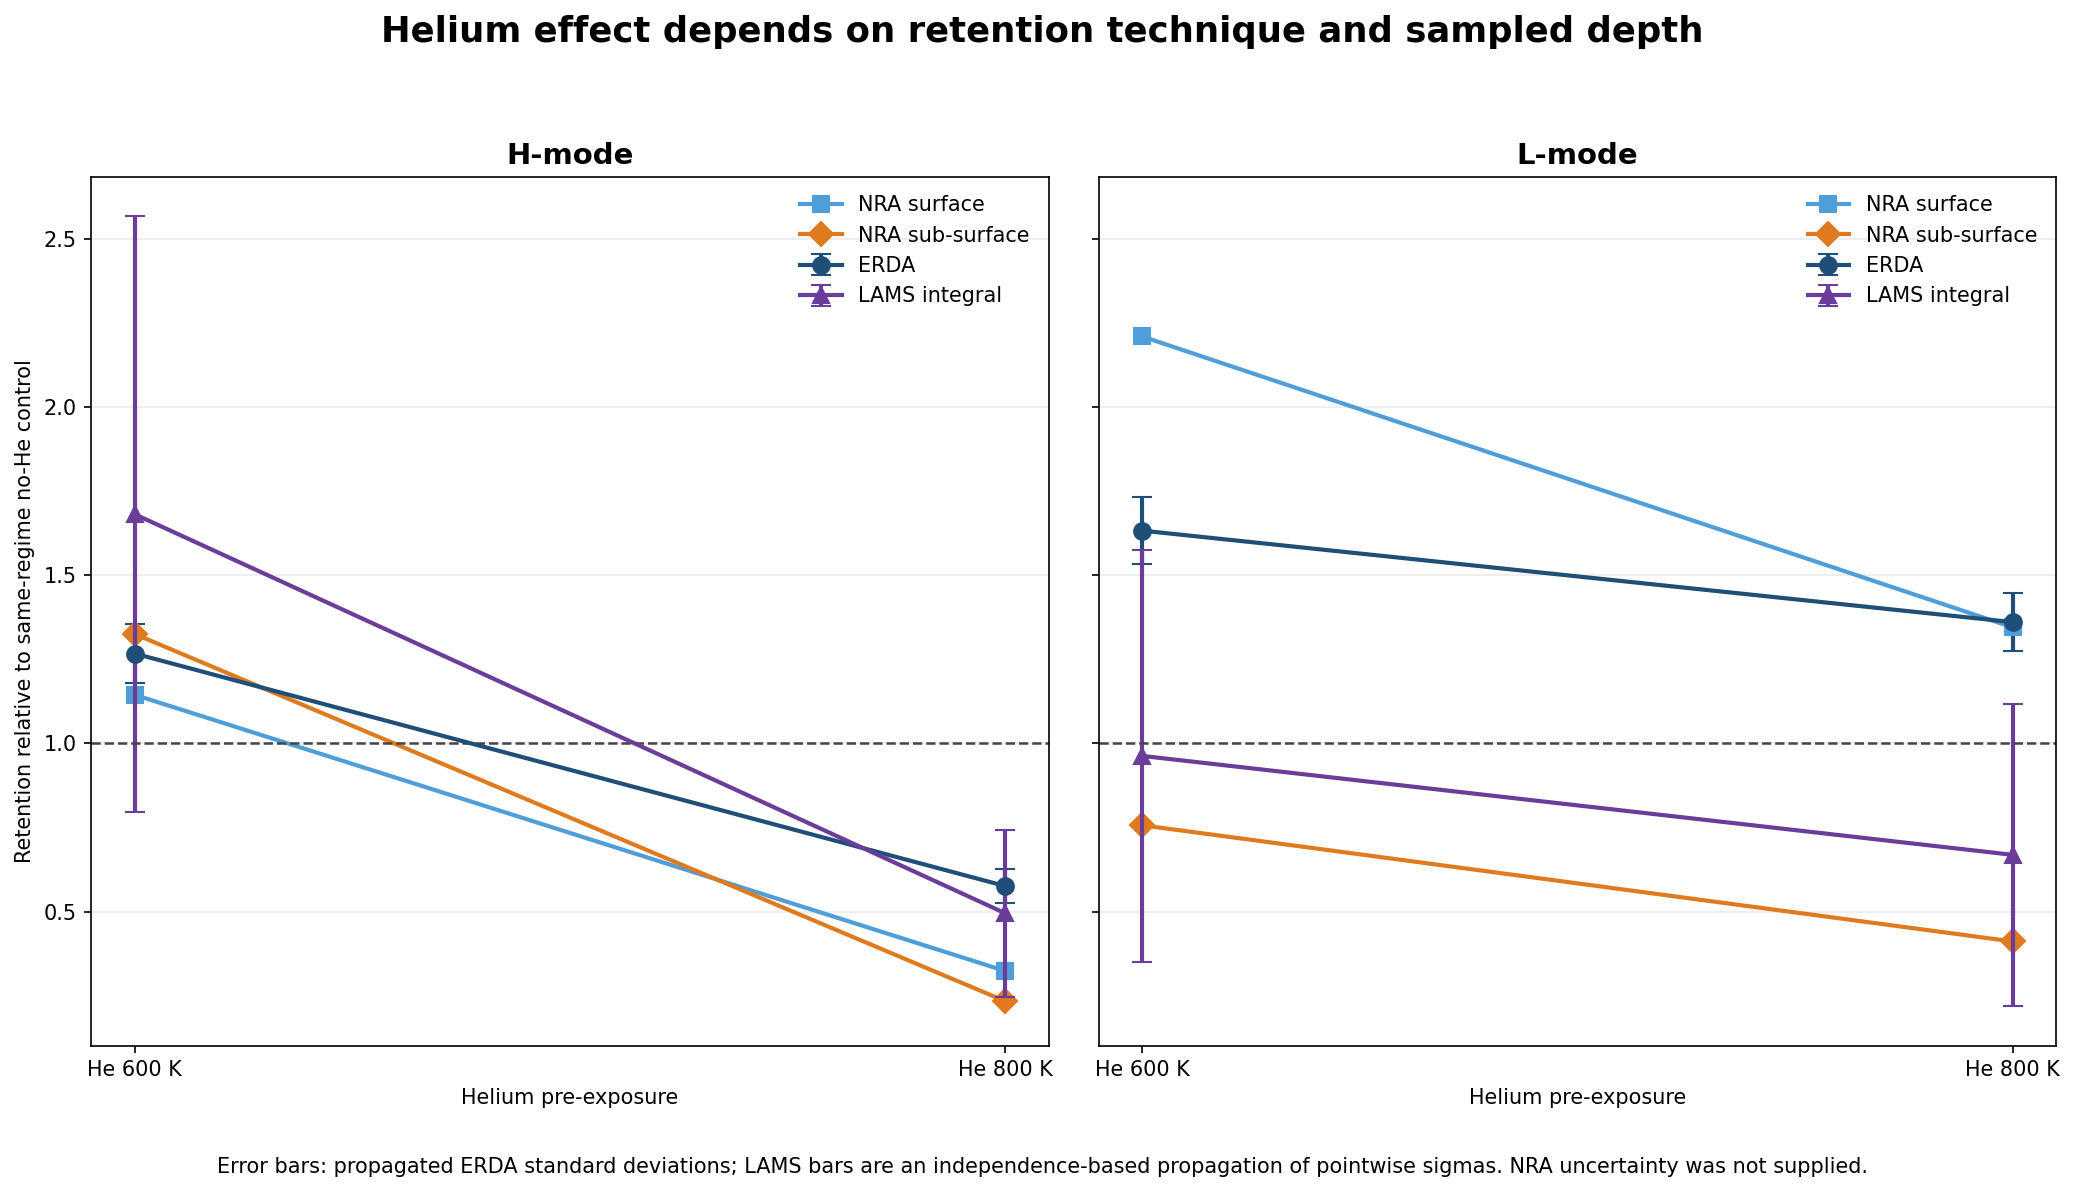

## What the dataset is not sufficient to claim

### A universal helium effect

The measurements do not support “helium always reduces D retention” or “helium always increases D retention.” The direction changes with:

- helium-treatment condition;
- DIII-D exposure campaign;
- measurement technique;
- sampled depth.

Averaging all helium-treated coupons together would erase the principal result.

### A population-level or statistically replicated treatment effect

Every one of the nine experimental cells contains **one coupon** . Consequently, the study has no direct estimate of:

- coupon-to-coupon variability;
- initial surface heterogeneity among nominally equivalent coupons;
- repeatability of the PISCES treatment;
- repeatability of the complete DIII-D exposure and post-mortem measurement sequence.

The ERDA changes are often large compared with ERDA’s reported standard deviations, but those standard deviations describe the measurement of an individual coupon. They do not replace independent coupon replication.

### A pure helium-temperature effect

The 600 K and 800 K PISCES exposures differed in more than temperature. Fluence, flux, and duration also changed. The data therefore support differences between the two delivered PISCES treatment conditions, not a clean temperature-response curve.

### A pure L-mode versus H-mode effect

The two DIII-D campaigns differed in several incident conditions and used different shot sets. The results cannot separate confinement mode from the accompanying differences in heat flux, particle flux, fluence, impact energy, duration, $n_e$, or $T_e$.

Most importantly, the provider confirms that neither bulk nor surface coupon temperature was measured during DIII-D exposure. Because temperature can alter diffusion, trapping, and thermal release, it is an unresolved confounder.

### A method-independent whole-coupon D inventory

The provider explicitly states that ERDA, NRA, and LAMS are not interchangeable and should not be ranked or averaged.

- **ERDA** supplies a scalar areal-density result with reported standard deviations.
- **NRA** supplies two depth bands but no delivered uncertainty values.
- **LAMS** supplies detailed profiles over 0.024–2.155 µm, but with large pointwise sigmas.

The delivered ERDA scalar may reasonably be called the ERDA “total” in contrast to the depth-binned measurements, but the three methods together do not establish a method-independent, full-depth inventory of all D in the coupon.

### Fine depth-by-depth differences with high statistical confidence

The uncertainty record is uneven:

- ERDA’s supplied relative standard deviations range from **3.8% to 7.2%** .
- NRA has **no supplied uncertainty column** .
- LAMS treated-coupon pointwise relative sigmas range from **56.9% to 198.9%** ; median relative sigma by treated profile ranges from **82.1% to 102.8%** .
- No LAMS covariance information is provided for integrating adjacent depth points.

The LAMS point estimates are valuable for identifying profile shape and sign patterns, but individual depth differences should not be presented as sharply resolved quantitative boundaries.

### Proof of a helium-nanobubble permeation barrier

The delivery does not establish:

1. the post-DIII-D existence and dimensions of the proposed bubble layer;
2. bubble density or void fraction;
3. spatial correspondence between bubbles and retained D;
4. a changed D permeation coefficient;
5. a changed recycling fraction.

The measured profiles are consistent with such a mechanism, but consistency is not identification. Alternative contributions—including temperature-dependent release, altered trapping, surface chemistry, and spatial heterogeneity—remain possible.

## What further measurement is needed?

No single measurement resolves every limitation. The required next measurement depends on the intended claim.

| Intended claim | Most important next measurement or design change | What it would resolve |
|---|---|---|
| Helium causally changes D retention | Replicated coupons in every treatment cell, with helium temperature, flux, fluence, and duration varied independently | Separates treatment effects from coupon variability and identifies which helium parameter matters |
| L-mode and H-mode cause different retention | Matched L/H exposures holding other incident conditions as constant as possible, with direct coupon-temperature monitoring | Separates confinement mode from heat flux, fluence, impact energy, duration, and thermal history |
| One condition changes the full retained-D inventory | Thermal desorption spectroscopy on matched sacrificial replicate coupons | Supplies an independent integrated released-D inventory and a release-temperature spectrum sensitive to trap populations |
| Helium redistributes D with depth | Co-located, replicated depth profiles extending through and beyond the currently sampled region | Tests whether surface enrichment is balanced by deeper depletion and reduces spatial-sampling ambiguity |
| A helium-bubble layer causes the change | Post-DIII-D cross-sectional FIB/SEM or TEM, correlated with the D depth profile | Directly measures bubble-layer thickness, morphology, and spatial relation to D retention |
| Altered recycling or permeation is the mechanism | Time-resolved Dα/D$_2$ recycling measurements or a direct D permeation experiment | Distinguishes reduced inward uptake, enhanced return to the plasma, and altered bulk transport |

### Highest-priority design improvement

For any causal or population-level conclusion, the first requirement is **replicated coupons under matched conditions** , together with direct surface or bulk temperature measurements during DIII-D exposure. Without replication, another instrument on the same single coupon can improve characterization but cannot estimate full-process variability.

### Best additional technique for “total retention”

If one additional measurement technique must be selected specifically to clarify total retained D, the strongest complement would be **thermal desorption spectroscopy on matched sacrificial replicates** . TDS would provide:

- an independently integrated desorbed-D inventory;
- release spectra that distinguish changes in trap-release behavior;
- a bridge to the Baldwin and Doerner transport analysis, which used TDS plus modeling.

It should complement, not replace, NRA or LAMS: TDS sacrifices spatial depth information, while the existing methods show that depth redistribution is central to the result.

### Best additional measurement for the proposed mechanism

To claim a helium-nanobubble transport barrier, the essential missing evidence is **post-DIII-D cross-sectional microscopy** , preferably TEM or sufficiently resolved FIB/SEM, on the same treatment classes. It should quantify bubble-layer thickness and morphology and be paired with a co-located D profile.

This is not merely a generic recommendation. The delivered experimental proposal explicitly planned:

- surface SEM and cross-sectional FIB/SEM before and after DIII-D;
- time-resolved Dα and D$_2$ recycling measurements;
- post-mortem ERDA and LAMS profiles.

The current delivery contains the retention measurements and pre-DIII-D microscopy, but it does not contain a corresponding post-DIII-D cross-sectional image record demonstrating the proposed structure.

## Overall evidentiary conclusion

The most defensible collective conclusion is:

> These tungsten coupons exhibit reproducible-looking but unreplicated, condition-specific changes in D retention. The H-mode measurements show cross-technique agreement that the 600 K helium condition raised retention while the 800 K condition lowered it; the L-mode measurements show that near-surface enrichment can coexist with depletion at greater depth. Together, the results support altered near-surface D transport or trapping as a working interpretation, but they do not establish a universal helium effect, an isolated confinement-mode or temperature effect, or a helium-nanobubble permeation-barrier mechanism.

The next study should therefore combine **replicated matched coupons** , **direct DIII-D coupon-temperature measurements** , **TDS for independent integrated inventory** , and **post-DIII-D cross-sectional microscopy correlated with depth-resolved D measurements** .

## Data files

- [`collective_retention_numeric_evidence.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/collective_retention_numeric_evidence.csv) — all helium-versus-control and L-versus-H comparisons by method and depth range, including ratios and propagated uncertainties where available.
- [`collective_retention_uncertainty_limits.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/collective_retention_uncertainty_limits.csv) — delivered uncertainty coverage and its inferential limitations.
- [`collective_retention_claim_boundaries.csv`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/collective_retention_claim_boundaries.csv) — supported findings, unsupported extensions, and the measurement needed for each stronger claim.
- [`collective_retention_evidence_live.json`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/collective_retention_evidence_live.json) — live lakehouse response containing the measurements, experimental design, exposure conditions, provider notes, artifact catalogue, document matches, and literature passages.
- [`followup_measurement_document_context.json`](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/followup_measurement_document_context.json) — extracted proposal passages describing intended temperature, recycling, retention, and before/after microscopy measurements.

## Reference

M.J. Baldwin and R.P. Doerner (2017) Hydrogen isotope transport across tungsten surfaces exposed to a fusion relevant He ion fluence. Nuclear Fusion 57 076031 doi:10.1088/1741-4326/aa70b1

In [4]:
%%ask
Given these tungsten samples and the retention measurements delivered with
them, what do the results collectively support, what would they not be
sufficient to claim, and what further measurement would be needed?